# 2. RT-DETR-L for the AMIA Public Challenge 2026

This notebook solves the object-detection part of Midterm 2 using the trained RT-DETR-L run stored in the repository. The goal is not to retrain the detector locally. The goal is to make the modeling choice, dataset contract, training evidence, and submitted model behavior auditable from the artifacts already produced in `midterms/02/kaggle/output`.

The local source of truth is:

- raw competition metadata in `midterms/02/data/raw/amia-public-challenge-2026`;
- detector-formatted Kaggle dataset metadata in `midterms/02/kaggle/output/amia-detector`;
- the trained run `rtdetr-l-e20-b8-t4x2-ddpfix-t10h5` in `midterms/02/kaggle/output/models`;
- the final selected weights `weights/best.pt` and the saved validation plots from that run.

The notebook follows the same philosophy as the other midterm solutions: start from the mathematical contract, then inspect the data, then load and interpret the trained artifact, and only then discuss empirical evidence.


## 2.1. Detection problem and notation

A chest radiograph is an image

$$
x \in [0,1]^{H \times W \times C},
$$

and each annotated abnormality is represented by a class label and a bounding box

$$
y_j = (c_j, b_j),
\qquad
c_j \in \{0,1,\ldots,13\},
\qquad
b_j=(x_{\min},y_{\min},x_{\max},y_{\max}).
$$

The competition metadata also contains class `14 = No finding`. That class is not a localized object. It has no meaningful bounding box and therefore is not part of the detector target space. It is a submission fallback class used when the detector produces no accepted boxes for an image. Thus the detector is trained over the localized classes

$$
\mathcal C_{det}=\{0,1,\ldots,13\},
$$

while the submission post-processing may emit class 14 for empty detections.

For one image, an object detector returns a finite set

$$
\widehat{Y}(x)=\{(\widehat c_k,\widehat b_k,\widehat s_k)\}_{k=1}^{K},
$$

where $\widehat s_k \in [0,1]$ is the confidence score. Performance is evaluated by matching predicted and true boxes through intersection-over-union,

$$
\operatorname{IoU}(b,\widehat b)
=\frac{|b\cap \widehat b|}{|b\cup \widehat b|},
$$

and summarizing precision-recall behavior as average precision and mean average precision. For a class $c$, average precision is the area under the precision-recall curve,

$$
\operatorname{AP}_c = \int_0^1 p_c(r)\,dr,
$$

and the reported mean average precision is

$$
\operatorname{mAP} = \frac{1}{|\mathcal C_{det}|}\sum_{c\in\mathcal C_{det}} \operatorname{AP}_c.
$$

The `mAP50` column uses an IoU threshold of $0.50$. The `mAP50-95` column averages over thresholds $0.50,0.55,\ldots,0.95$ and is therefore stricter.


## 2.2. Imports and repository paths

The cells below use standard data and plotting libraries. The optional model-loading cell uses Ultralytics only if it is installed in the active environment. The saved run artifacts are still inspected even when the local machine does not have PyTorch or Ultralytics installed.


In [27]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    MIDTERM_DIR = NOTEBOOK_DIR.parent
else:
    MIDTERM_DIR = Path("midterms/02")

RAW_DIR = MIDTERM_DIR / "data" / "raw" / "amia-public-challenge-2026"
OUTPUT_DIR = MIDTERM_DIR / "kaggle" / "output"
DETECTOR_DIR = OUTPUT_DIR / "amia-detector"
RUN_NAME = "rtdetr-l-e20-b8-t4x2-ddpfix-t10h5"
RUN_DIR = OUTPUT_DIR / "models" / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"
BEST_WEIGHTS = WEIGHTS_DIR / "best.pt"

paths = {
    "train_csv": RAW_DIR / "train.csv",
    "test_csv": RAW_DIR / "test.csv",
    "img_size_csv": RAW_DIR / "img_size.csv",
    "sample_submission_csv": RAW_DIR / "sample_submission.csv",
    "dataset_yaml": DETECTOR_DIR / "dataset.yaml",
    "run_dir": RUN_DIR,
    "best_weights": BEST_WEIGHTS,
    "results_csv": RUN_DIR / "results.csv",
    "submission_summary": RUN_DIR / "submission-summary.json",
    "dataset_summary": MIDTERM_DIR / "artifacts" / "reports" / "dataset-summary.json",
}

for name, path in paths.items():
    print(f"{name:24s}: {path}  exists={path.exists()}")


train_csv               : /home/mitin/code/ml-theory/midterms/02/data/raw/amia-public-challenge-2026/train.csv  exists=True
test_csv                : /home/mitin/code/ml-theory/midterms/02/data/raw/amia-public-challenge-2026/test.csv  exists=True
img_size_csv            : /home/mitin/code/ml-theory/midterms/02/data/raw/amia-public-challenge-2026/img_size.csv  exists=True
sample_submission_csv   : /home/mitin/code/ml-theory/midterms/02/data/raw/amia-public-challenge-2026/sample_submission.csv  exists=True
dataset_yaml            : /home/mitin/code/ml-theory/midterms/02/kaggle/output/amia-detector/dataset.yaml  exists=True
run_dir                 : /home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5  exists=True
best_weights            : /home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/weights/best.pt  exists=True
results_csv             : /home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtd

## 2.3. Dataset structure

The raw competition files define three different contracts:

1. `train.csv` gives the supervised training annotations. Rows with `No finding` have no box coordinates, while rows with findings have a localized box.
2. `img_size.csv` defines the original pixel geometry for every image. This matters because detector training converts absolute boxes into normalized coordinates.
3. `test.csv` and `sample_submission.csv` define the inference contract. The sample submission contains one row per unique test image.

The Kaggle training notebook converts the localized rows to the YOLO/Ultralytics detector format. In that format each object row is

$$
(c, x_c, y_c, w, h),
$$

where the four geometry values are normalized to $[0,1]$. The conversion from absolute corners is

$$
x_c = \frac{x_{\min}+x_{\max}}{2W},\qquad
 y_c = \frac{y_{\min}+y_{\max}}{2H},
$$

$$
w = \frac{x_{\max}-x_{\min}}{W},\qquad
h = \frac{y_{\max}-y_{\min}}{H}.
$$

This is the first important boundary in the solution: labels are stored in a detector-normalized format, but interpretation and clinical review happen in original image coordinates.


In [28]:
train_df = pd.read_csv(paths["train_csv"])
test_df = pd.read_csv(paths["test_csv"])
img_size_df = pd.read_csv(paths["img_size_csv"])
sample_submission_df = pd.read_csv(paths["sample_submission_csv"])

summary = pd.DataFrame(
    [
        {"file": "train.csv", "rows": len(train_df), "unique_images": train_df["image_id"].nunique()},
        {"file": "test.csv", "rows": len(test_df), "unique_images": test_df["image_id"].nunique()},
        {"file": "img_size.csv", "rows": len(img_size_df), "unique_images": img_size_df["image_id"].nunique()},
        {
            "file": "sample_submission.csv",
            "rows": len(sample_submission_df),
            "unique_images": sample_submission_df["image_id"].nunique(),
        },
    ]
)
display(summary)

print("Train columns:", list(train_df.columns))
print("Image-size columns:", list(img_size_df.columns))


,file,rows,unique_images
0,train.csv,45925,8573
1,test.csv,21989,6427
2,img_size.csv,15000,15000
3,sample_submission.csv,6427,6427


Train columns: ['image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min', 'x_max', 'y_max']
Image-size columns: ['image_id', 'dim0', 'dim1']


## 2.4. Class imbalance and detector target counts

The most important dataset plot is the class-count distribution. Object detection is not only a classification problem; an image may contain multiple findings and multiple boxes. Therefore the count below is an annotation-row count, not an image count.

The imbalance is mathematically relevant because the empirical risk optimized by the detector is a finite-sample average. If class $c$ appears $n_c$ times, then before any sampling or augmentation its direct contribution frequency is approximately

$$
\pi_c = \frac{n_c}{\sum_{k} n_k}.
$$

Rare classes such as pneumothorax or atelectasis provide fewer positive matching examples, so their gradients are noisier and their precision-recall curves are less stable. Frequent classes such as `No finding`, aortic enlargement, pleural thickening, and pulmonary fibrosis dominate the raw annotation table. Since `No finding` has no box, it must be separated from the detector classes.


,class_id,class_name,annotation_rows,detector_target,frequency
14,14,No finding,15525,False,0.338051
0,0,Aortic enlargement,5481,True,0.119347
11,11,Pleural thickening,4308,True,0.093805
13,13,Pulmonary fibrosis,4097,True,0.089211
3,3,Cardiomegaly,4046,True,0.088100
8,8,Nodule/Mass,2324,True,0.050604
10,10,Pleural effusion,2190,True,0.047686
7,7,Lung Opacity,2188,True,0.047643
9,9,Other lesion,1945,True,0.042352
6,6,Infiltration,1097,True,0.023887


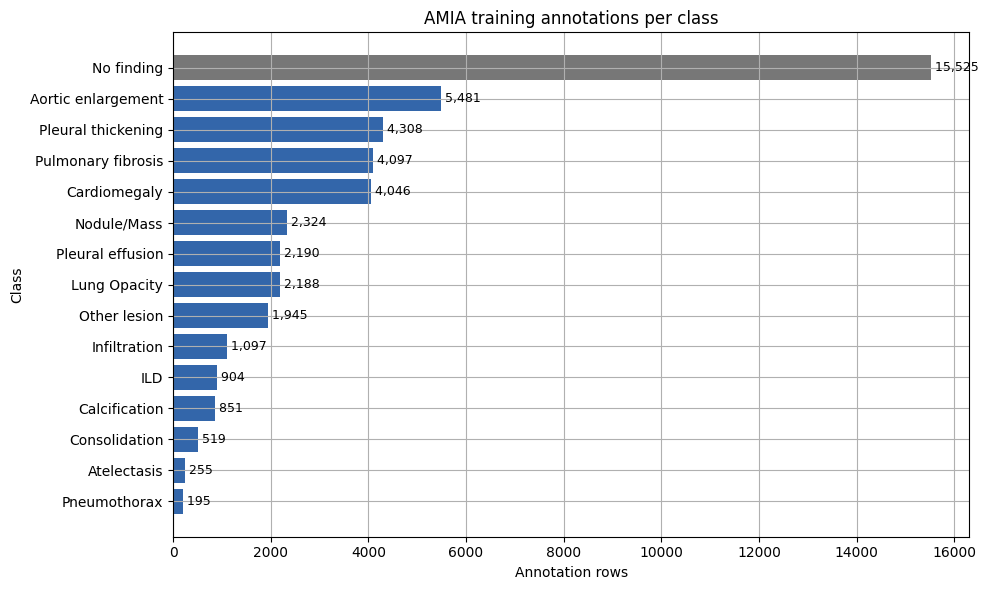

Localized detector annotations: 30,400
No-finding rows excluded from detector labels: 15,525


In [29]:
class_counts = (
    train_df.groupby(["class_id", "class_name"], dropna=False)
    .size()
    .rename("annotation_rows")
    .reset_index()
    .sort_values("annotation_rows", ascending=False)
)
class_counts["class_id"] = class_counts["class_id"].astype(int)
class_counts["detector_target"] = class_counts["class_id"] != 14
class_counts["frequency"] = class_counts["annotation_rows"] / class_counts["annotation_rows"].sum()

display(class_counts)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = class_counts.sort_values("annotation_rows", ascending=True)
colors = np.where(plot_df["class_id"].eq(14), "#777777", "#3366AA")
ax.barh(plot_df["class_name"], plot_df["annotation_rows"], color=colors)
ax.set_xlabel("Annotation rows")
ax.set_ylabel("Class")
ax.set_title("AMIA training annotations per class")
for index, value in enumerate(plot_df["annotation_rows"]):
    ax.text(value, index, f" {value:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

localized_df = train_df[train_df["class_id"] != 14].copy()
print(f"Localized detector annotations: {len(localized_df):,}")
print(f"No-finding rows excluded from detector labels: {(train_df['class_id'] == 14).sum():,}")


## 2.5. Image-level multiplicity and box geometry

Class counts alone are not enough for detection. A detector must also learn how many findings may appear in one image and the typical scale of the boxes. For each image $i$, define

$$
m_i = |\{j: y_{ij}\;\text{is a localized finding}\}|.
$$

Images with $m_i=0$ are negative examples for every localized class. Images with large $m_i$ create denser matching problems. The box area fraction

$$
a_j = \frac{(x_{\max,j}-x_{\min,j})(y_{\max,j}-y_{\min,j})}{W_jH_j}
$$

is also important: small findings require high-resolution spatial features, while very large findings stress global context and box calibration.


,count,mean,std,min,25%,50%,75%,max
localized_objects,8573.0,3.546017,5.485474,0.0,0.0,0.0,6.0,57.0


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
box_area_fraction,30400.0,0.029942,0.040032,0.000023,0.000249,0.000819,0.005089,0.014372,0.042932,0.10139,0.198799,0.938427


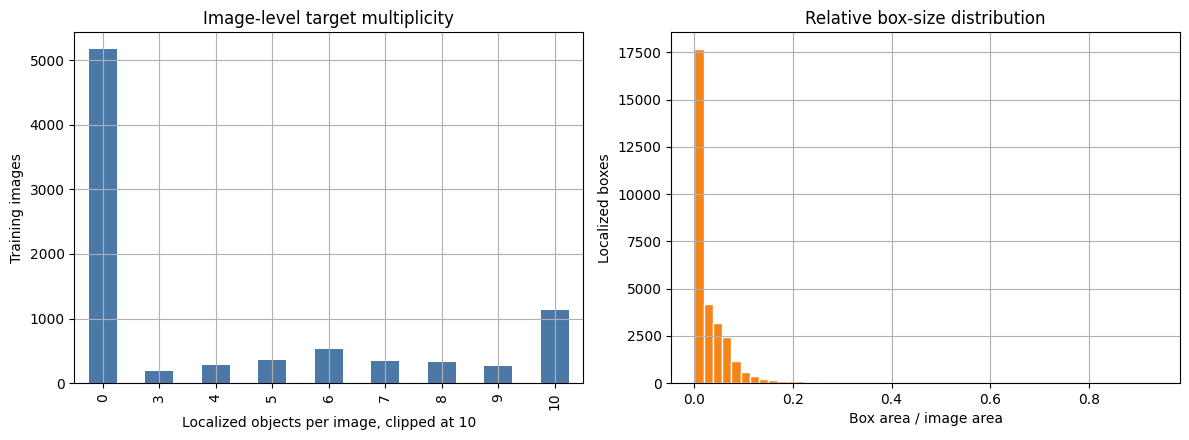

In [30]:
localized_with_size = localized_df.merge(img_size_df, on="image_id", how="left", validate="many_to_one")
missing_size = localized_with_size[["dim0", "dim1"]].isna().any(axis=1).sum()
if missing_size:
    raise ValueError(f"Missing image-size rows for {missing_size} localized annotations")

localized_with_size["box_width"] = localized_with_size["x_max"] - localized_with_size["x_min"]
localized_with_size["box_height"] = localized_with_size["y_max"] - localized_with_size["y_min"]
localized_with_size["box_area_fraction"] = (
    localized_with_size["box_width"] * localized_with_size["box_height"]
) / (localized_with_size["dim1"] * localized_with_size["dim0"])

objects_per_image = localized_df.groupby("image_id").size().rename("localized_objects")
all_train_images = pd.Index(train_df["image_id"].unique(), name="image_id")
objects_per_image = objects_per_image.reindex(all_train_images, fill_value=0).reset_index()

display(objects_per_image["localized_objects"].describe().to_frame().T)
display(localized_with_size["box_area_fraction"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
objects_per_image["localized_objects"].clip(upper=10).value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_xlabel("Localized objects per image, clipped at 10")
axes[0].set_ylabel("Training images")
axes[0].set_title("Image-level target multiplicity")

axes[1].hist(localized_with_size["box_area_fraction"], bins=50, color="#F58518", edgecolor="white")
axes[1].set_xlabel("Box area / image area")
axes[1].set_ylabel("Localized boxes")
axes[1].set_title("Relative box-size distribution")
plt.tight_layout()
plt.show()


## 2.6. Dataset conversion contract checks

The repository includes a saved `dataset-summary.json` produced after building the Kaggle detector dataset. These checks are contract checks, not model metrics. They verify that the raw CSV rows and local PNG files agreed when the dataset was built.


In [31]:
with open(paths["dataset_summary"], "r", encoding="utf-8") as handle:
    dataset_summary = json.load(handle)

print(json.dumps(dataset_summary["contract_checks"], indent=2))
print(json.dumps(dataset_summary["image_counts"], indent=2))

summary_classes = pd.DataFrame(dataset_summary["classes"])
summary_classes["class_id"] = summary_classes["class_id"].astype(int)
summary_classes = summary_classes.sort_values("class_id")
display(summary_classes)


{
  "image_size_rows_cover_all_pngs": true,
  "sample_submission_has_unique_images": true,
  "sample_submission_images_match_test_pngs": true,
  "train_csv_images_match_pngs": true
}
{
  "all_images_with_size_rows": 15000,
  "test_duplicate_rows_in_test_csv": 15562,
  "test_png": 6427,
  "test_rows_in_test_csv": 21989,
  "test_unique_in_sample_submission": 6427,
  "test_unique_in_test_csv": 6427,
  "train_png": 8573,
  "train_unique_in_csv": 8573
}


,annotation_rows,class_id,class_name
0,5481,0,Aortic enlargement
1,255,1,Atelectasis
2,851,2,Calcification
3,4046,3,Cardiomegaly
4,519,4,Consolidation
5,904,5,ILD
6,1097,6,Infiltration
7,2188,7,Lung Opacity
8,2324,8,Nodule/Mass
9,1945,9,Other lesion


## 2.7. What RT-DETR-L is

RT-DETR-L is the large variant of a real-time Detection Transformer. Its prediction function can be written abstractly as

$$
f_\theta(x)=D_\theta\!\left(E_\theta(x)\right),
$$

where $E_\theta$ is the image feature encoder and $D_\theta$ is a transformer-style detection decoder. Unlike anchor-based dense detectors, the model predicts a fixed set of object queries. If there are $N_q$ queries, the raw output is

$$
\{(p_i,b_i)\}_{i=1}^{N_q},
\qquad
p_i\in[0,1]^{C},
\qquad
b_i\in[0,1]^4.
$$

Here $p_i$ is the class-probability vector and $b_i$ is the normalized box for query $i$. The decoder uses cross-attention between learned or selected object queries and image features, so each query can specialize to one candidate object.

The transformer attention operation is

$$
\operatorname{Attn}(Q,K,V)
=\operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V,
$$

where queries $Q$, keys $K$, and values $V$ are learned projections of object queries and image features. This operation lets a predicted box depend on distant image evidence, which is useful in chest radiographs because many findings are defined relative to bilateral anatomy, cardiac silhouette, pleural boundaries, or diffuse texture.


## 2.8. Matching loss and why DETR-style training is appropriate

A DETR-style detector treats object detection as set prediction. Let the true localized objects for an image be

$$
Y=\{(c_j,b_j)\}_{j=1}^{m},
$$

and the model produce $N_q\ge m$ candidate predictions. Training first solves a bipartite matching problem between truth boxes and prediction slots:

$$
\widehat\sigma
=\arg\min_{\sigma\in\mathfrak S_{N_q}}
\sum_{j=1}^{m}
\mathcal C\bigl((c_j,b_j),(\widehat p_{\sigma(j)},\widehat b_{\sigma(j)})\bigr),
$$

where a typical matching cost combines classification and localization terms,

$$
\mathcal C
= -\log \widehat p_{\sigma(j)}(c_j)
+ \lambda_1\lVert b_j-\widehat b_{\sigma(j)}\rVert_1
+ \lambda_{iou}\bigl(1-\operatorname{GIoU}(b_j,\widehat b_{\sigma(j)})\bigr).
$$

After matching, the optimized loss has the same structure:

$$
\mathcal L(\theta)
=\sum_{j=1}^{m}
\left[-\log \widehat p_{\widehat\sigma(j)}(c_j)
+ \lambda_1\lVert b_j-\widehat b_{\widehat\sigma(j)}\rVert_1
+ \lambda_{iou}\bigl(1-\operatorname{GIoU}(b_j,\widehat b_{\widehat\sigma(j)})\bigr)
\right]
+\mathcal L_{\varnothing}.
$$

The no-object term $\mathcal L_{\varnothing}$ trains unmatched queries to predict background. This is why the architecture is natural for the AMIA task: an image contains a set of zero or more findings, and the output should be a set rather than a fixed grid of independent anchor decisions.


## 2.9. Why RT-DETR-L was chosen

The model choice balances three constraints.

First, chest-radiograph findings are often spatially subtle and context-dependent. A transformer decoder is a good inductive bias because attention can relate a candidate lesion to global anatomy. Dense local features alone are not always enough for categories such as cardiomegaly, pleural thickening, fibrosis, or diffuse opacity.

Second, the Kaggle run had to finish under a practical session limit. RT-DETR is designed to avoid expensive post-hoc non-maximum suppression as the central detection mechanism, while still using a modern transformer set-prediction objective. The selected run used two T4 GPUs, 640-pixel inputs, and a wall-clock budget.

Third, the class distribution is highly imbalanced. A stronger large detector is preferable to a very small model because the rare classes need enough representation capacity to reuse features learned from frequent classes. The tradeoff is computational cost: the large model was trained for a limited number of epochs and must be judged by validation curves and saved predictions rather than by a claim of full convergence.


## 2.10. Trained run configuration and available weights

The run directory contains the training arguments, result curves, submission summary, validation visualizations, and checkpoint files. The selected checkpoint is `weights/best.pt`.


In [32]:
try:
    import yaml
except ImportError as exc:
    raise RuntimeError("PyYAML is required to read the saved RT-DETR configuration") from exc

with open(paths["dataset_yaml"], "r", encoding="utf-8") as handle:
    dataset_yaml = yaml.safe_load(handle)
with open(RUN_DIR / "args.yaml", "r", encoding="utf-8") as handle:
    train_args = yaml.safe_load(handle)

print("Detector classes from dataset.yaml:")
for class_id, class_name in dataset_yaml["names"].items():
    print(f"  {class_id}: {class_name}")

selected_args = {
    key: train_args[key]
    for key in [
        "model",
        "epochs",
        "time",
        "patience",
        "batch",
        "imgsz",
        "device",
        "workers",
        "optimizer",
        "pretrained",
        "amp",
        "iou",
        "max_det",
        "save_period",
        "deterministic",
        "project",
        "name",
    ]
    if key in train_args
}
display(pd.Series(selected_args, name="value").to_frame())

weight_rows = []
for path in sorted(WEIGHTS_DIR.glob("*.pt")):
    stat = path.stat()
    weight_rows.append({"checkpoint": path.name, "size_mb": stat.st_size / 1024**2})
weights_table = pd.DataFrame(weight_rows).sort_values("checkpoint")
display(weights_table)
print(f"Selected weights: {BEST_WEIGHTS}")


Detector classes from dataset.yaml:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis


,value
model,rtdetr-l.pt
epochs,20
time,10.5
patience,8
batch,8
imgsz,640
device,"0,1"
workers,4
optimizer,auto
pretrained,True


,checkpoint,size_mb
0,best.pt,63.199033
1,epoch0.pt,251.608132
2,epoch10.pt,251.609109
3,epoch15.pt,251.609719
4,epoch20.pt,251.610330
5,epoch25.pt,251.610940
6,epoch30.pt,251.611550
7,epoch35.pt,251.612161
8,epoch40.pt,251.612771
9,epoch5.pt,251.608499


Selected weights: /home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/weights/best.pt


## 2.11. Loading the trained model artifact

The next cell loads `weights/best.pt` when Ultralytics and PyTorch are installed. This is the actual trained checkpoint from the Kaggle run, not the initial pretrained `rtdetr-l.pt`. The local course environment used to execute this notebook may not include GPU training dependencies, so the cell is written as an explicit environment check instead of silently failing.


In [33]:
model = None
try:
    from ultralytics import RTDETR

    model = RTDETR(str(BEST_WEIGHTS))
    print("Loaded trained RT-DETR-L checkpoint")
    print(f"model task: {getattr(model, 'task', 'unknown')}")
    print(f"model names: {getattr(model, 'names', {})}")
    print(model)
except ModuleNotFoundError as exc:
    print("Ultralytics/PyTorch is not installed in this local environment.")
    print("The trained checkpoint is present and can be loaded with:")
    print(f"    from ultralytics import RTDETR; model = RTDETR({str(BEST_WEIGHTS)!r})")
    print(f"Missing dependency: {exc.name}")
except Exception as exc:
    print("The checkpoint exists, but local model loading failed in this environment.")
    print(type(exc).__name__, str(exc))


Loaded trained RT-DETR-L checkpoint
model task: detect
model names: {0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity', 8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening', 12: 'Pneumothorax', 13: 'Pulmonary fibrosis'}
RTDETR(
  (model): RTDETRDetectionModel(
    (model): Sequential(
      (0): HGStem(
        (stem1): Conv(
          (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem2a): Conv(
          (conv): Conv2d(32, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem2b): Conv(
         

## 2.12. Saved training curves

The saved `results.csv` gives one row per completed epoch and is the source of truth for the completed training trajectory. The run name and `args.yaml` record the requested Kaggle configuration, while the copied `results.csv` shows the actual epoch rows preserved in the artifact directory. The optimization terms are:

- `giou_loss`, a geometric overlap loss derived from generalized IoU;
- `cls_loss`, the class-prediction loss;
- `l1_loss`, a direct coordinate regression loss.

The key validation metrics are precision, recall, `mAP50`, and `mAP50-95`. Since `mAP50-95` averages over stricter IoU thresholds, it is expected to be much smaller than `mAP50` for medical findings with ambiguous or coarse boundaries.


Completed epoch rows in results.csv: 44
Last recorded epoch: 44


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
39,40,0.33433,0.35265,0.25586,0.13206
40,41,0.34376,0.35798,0.26589,0.13639
41,42,0.37528,0.32579,0.26558,0.13712
42,43,0.35141,0.33632,0.25975,0.13429
43,44,0.35156,0.35213,0.26477,0.13515


Best validation mAP50-95 row:


,value
epoch,36.00000
metrics/precision(B),0.33908
metrics/recall(B),0.36618
metrics/mAP50(B),0.27134
metrics/mAP50-95(B),0.14019


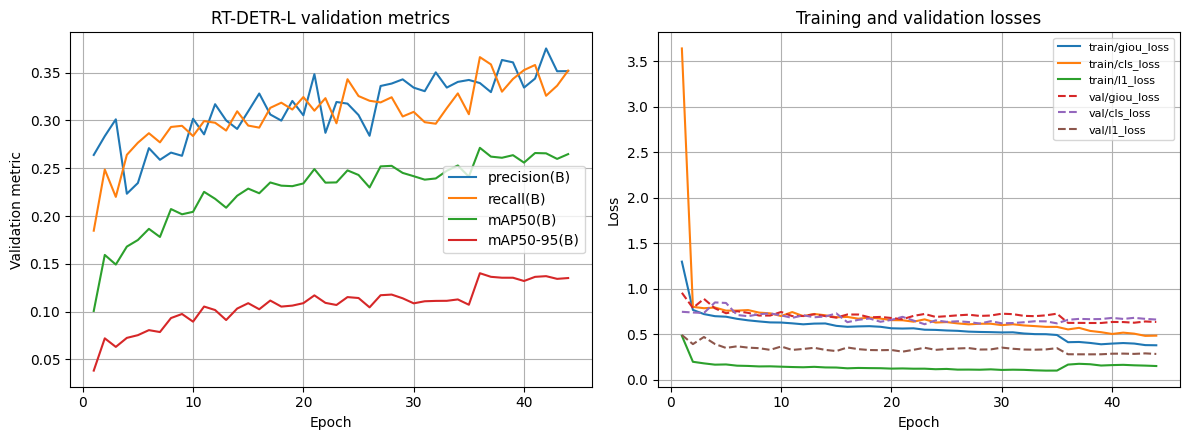

In [34]:
results = pd.read_csv(paths["results_csv"])
results.columns = [column.strip() for column in results.columns]
print(f"Completed epoch rows in results.csv: {len(results)}")
print(f"Last recorded epoch: {int(results['epoch'].max())}")
metric_cols = ["epoch", "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
loss_cols = ["epoch", "train/giou_loss", "train/cls_loss", "train/l1_loss", "val/giou_loss", "val/cls_loss", "val/l1_loss"]

display(results[metric_cols].tail())

best_map_row = results.loc[results["metrics/mAP50-95(B)"].idxmax()]
print("Best validation mAP50-95 row:")
display(best_map_row[metric_cols].to_frame("value"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for column in ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
    axes[0].plot(results["epoch"], results[column], label=column.replace("metrics/", ""))
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation metric")
axes[0].set_title("RT-DETR-L validation metrics")
axes[0].legend()

for column in ["train/giou_loss", "train/cls_loss", "train/l1_loss", "val/giou_loss", "val/cls_loss", "val/l1_loss"]:
    linestyle = "-" if column.startswith("train") else "--"
    axes[1].plot(results["epoch"], results[column], linestyle=linestyle, label=column)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training and validation losses")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2.13. Built-in run visualizations

The run folder already contains useful Ultralytics plots. These plots are part of the trained-model evidence:

- `labels.jpg` summarizes label locations and sizes after detector conversion;
- `results.png` summarizes optimization and validation curves;
- precision-recall and F1 curves show confidence-threshold behavior;
- confusion matrices expose class-level confusions;
- validation batch images compare labels and predictions qualitatively.


/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/labels.jpg


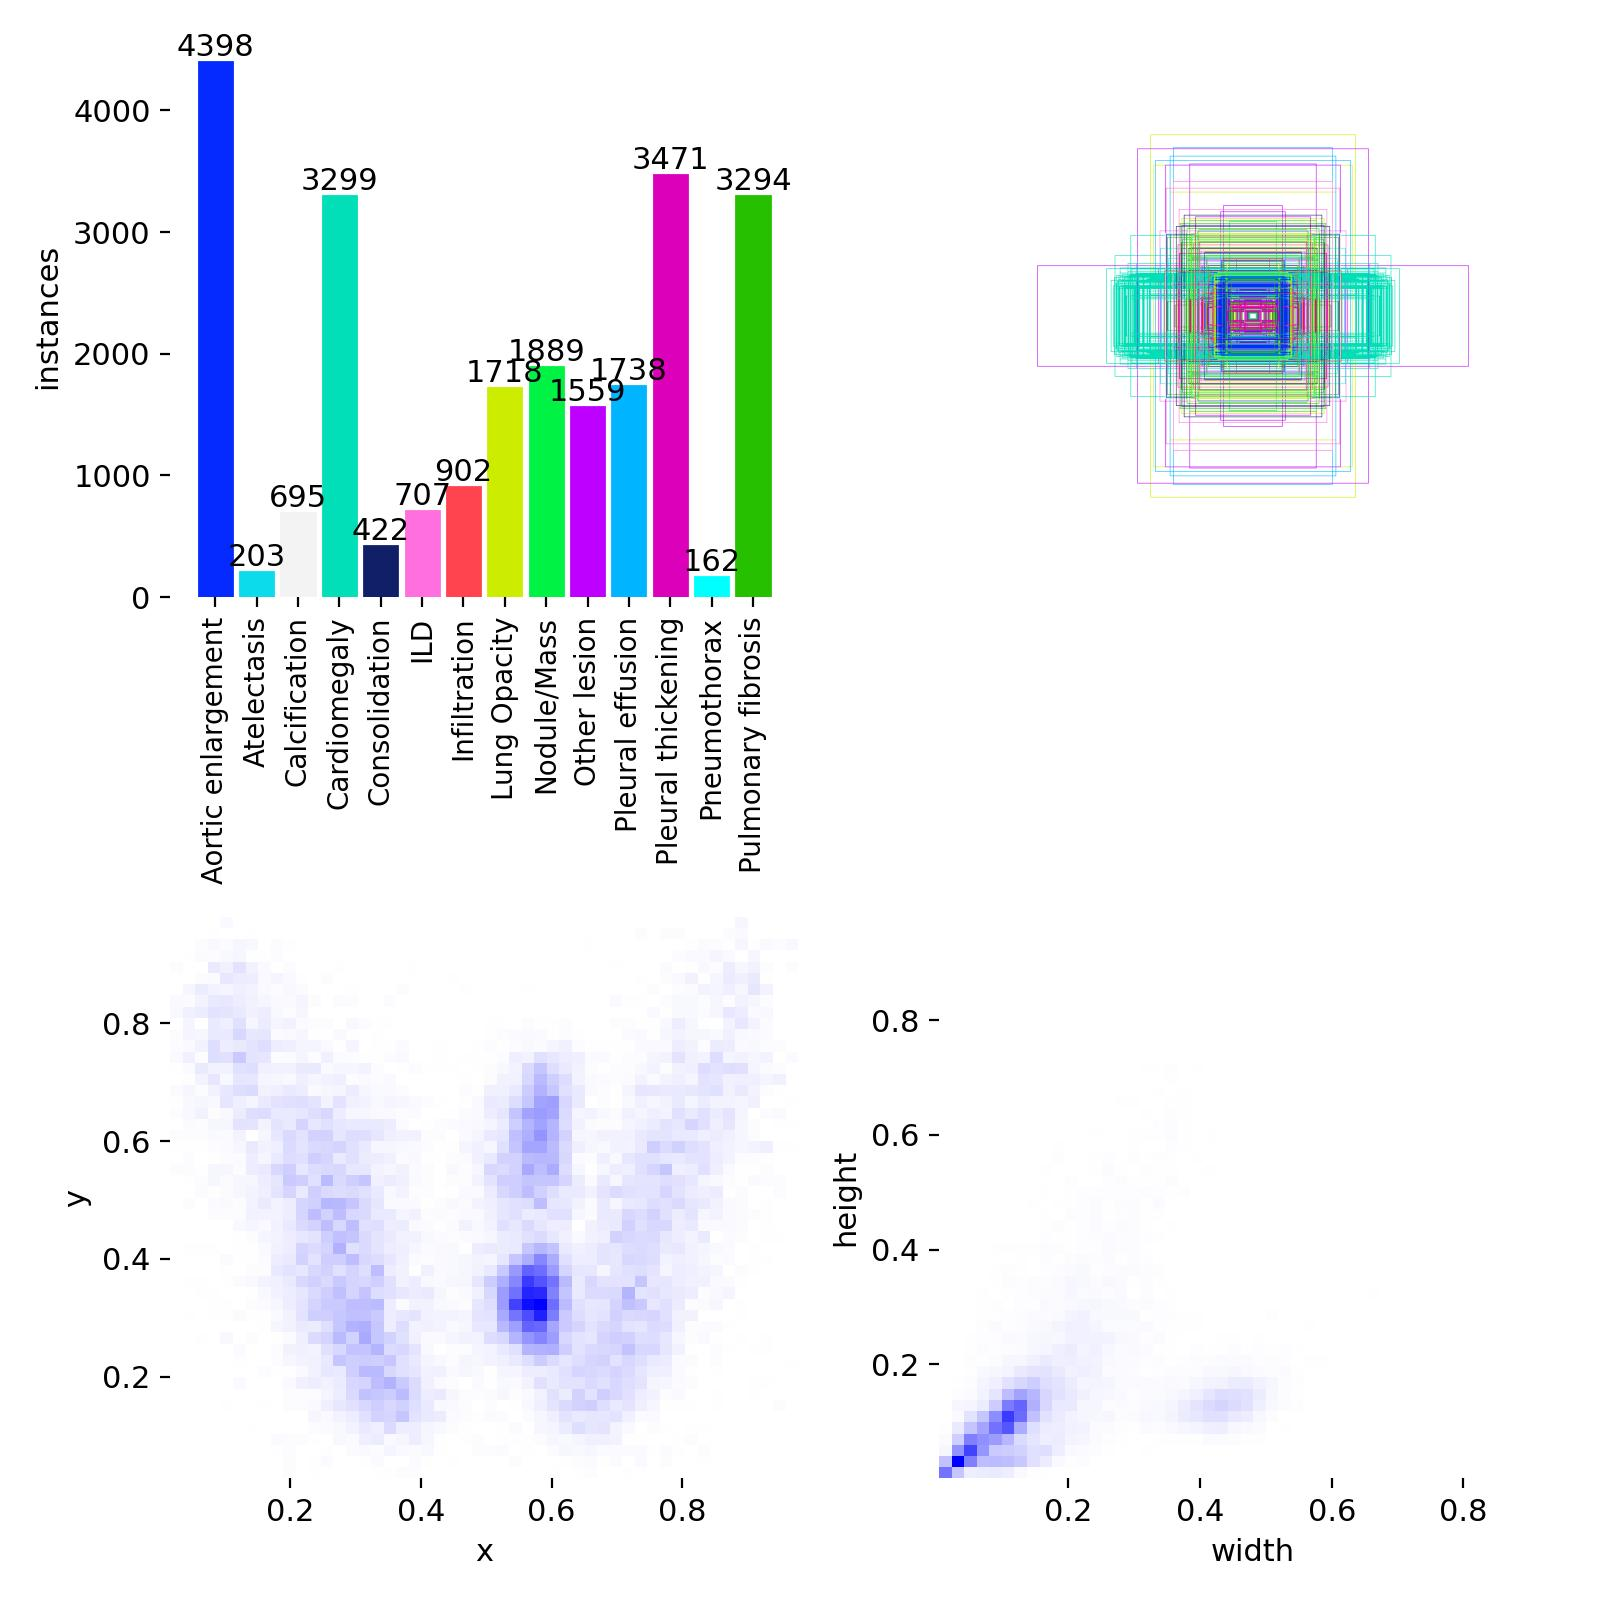

/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/results.png


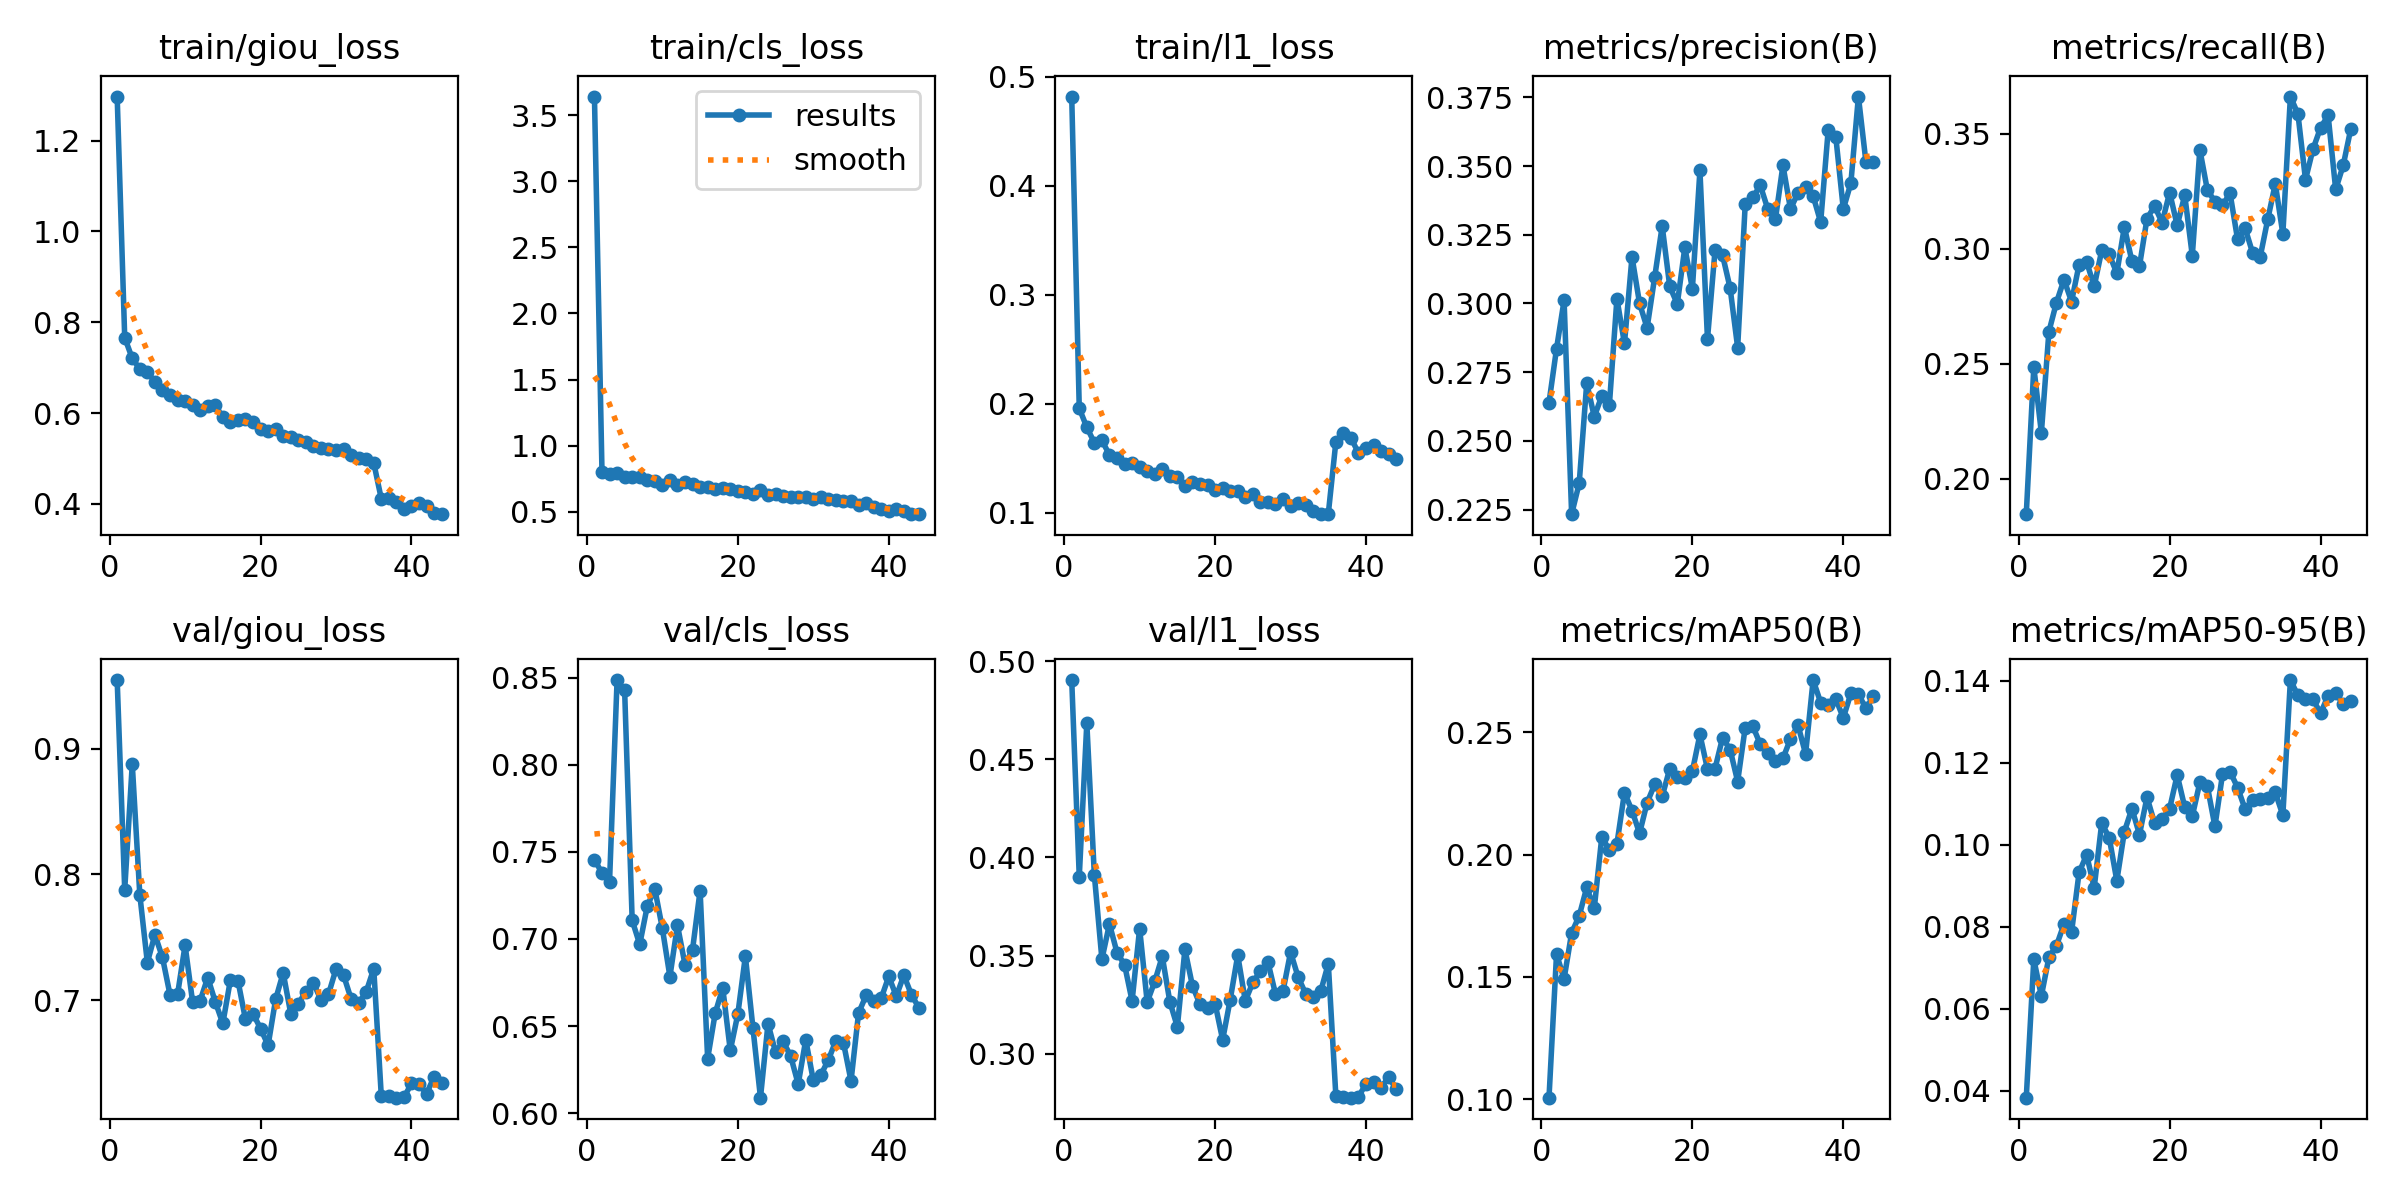

/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/BoxPR_curve.png


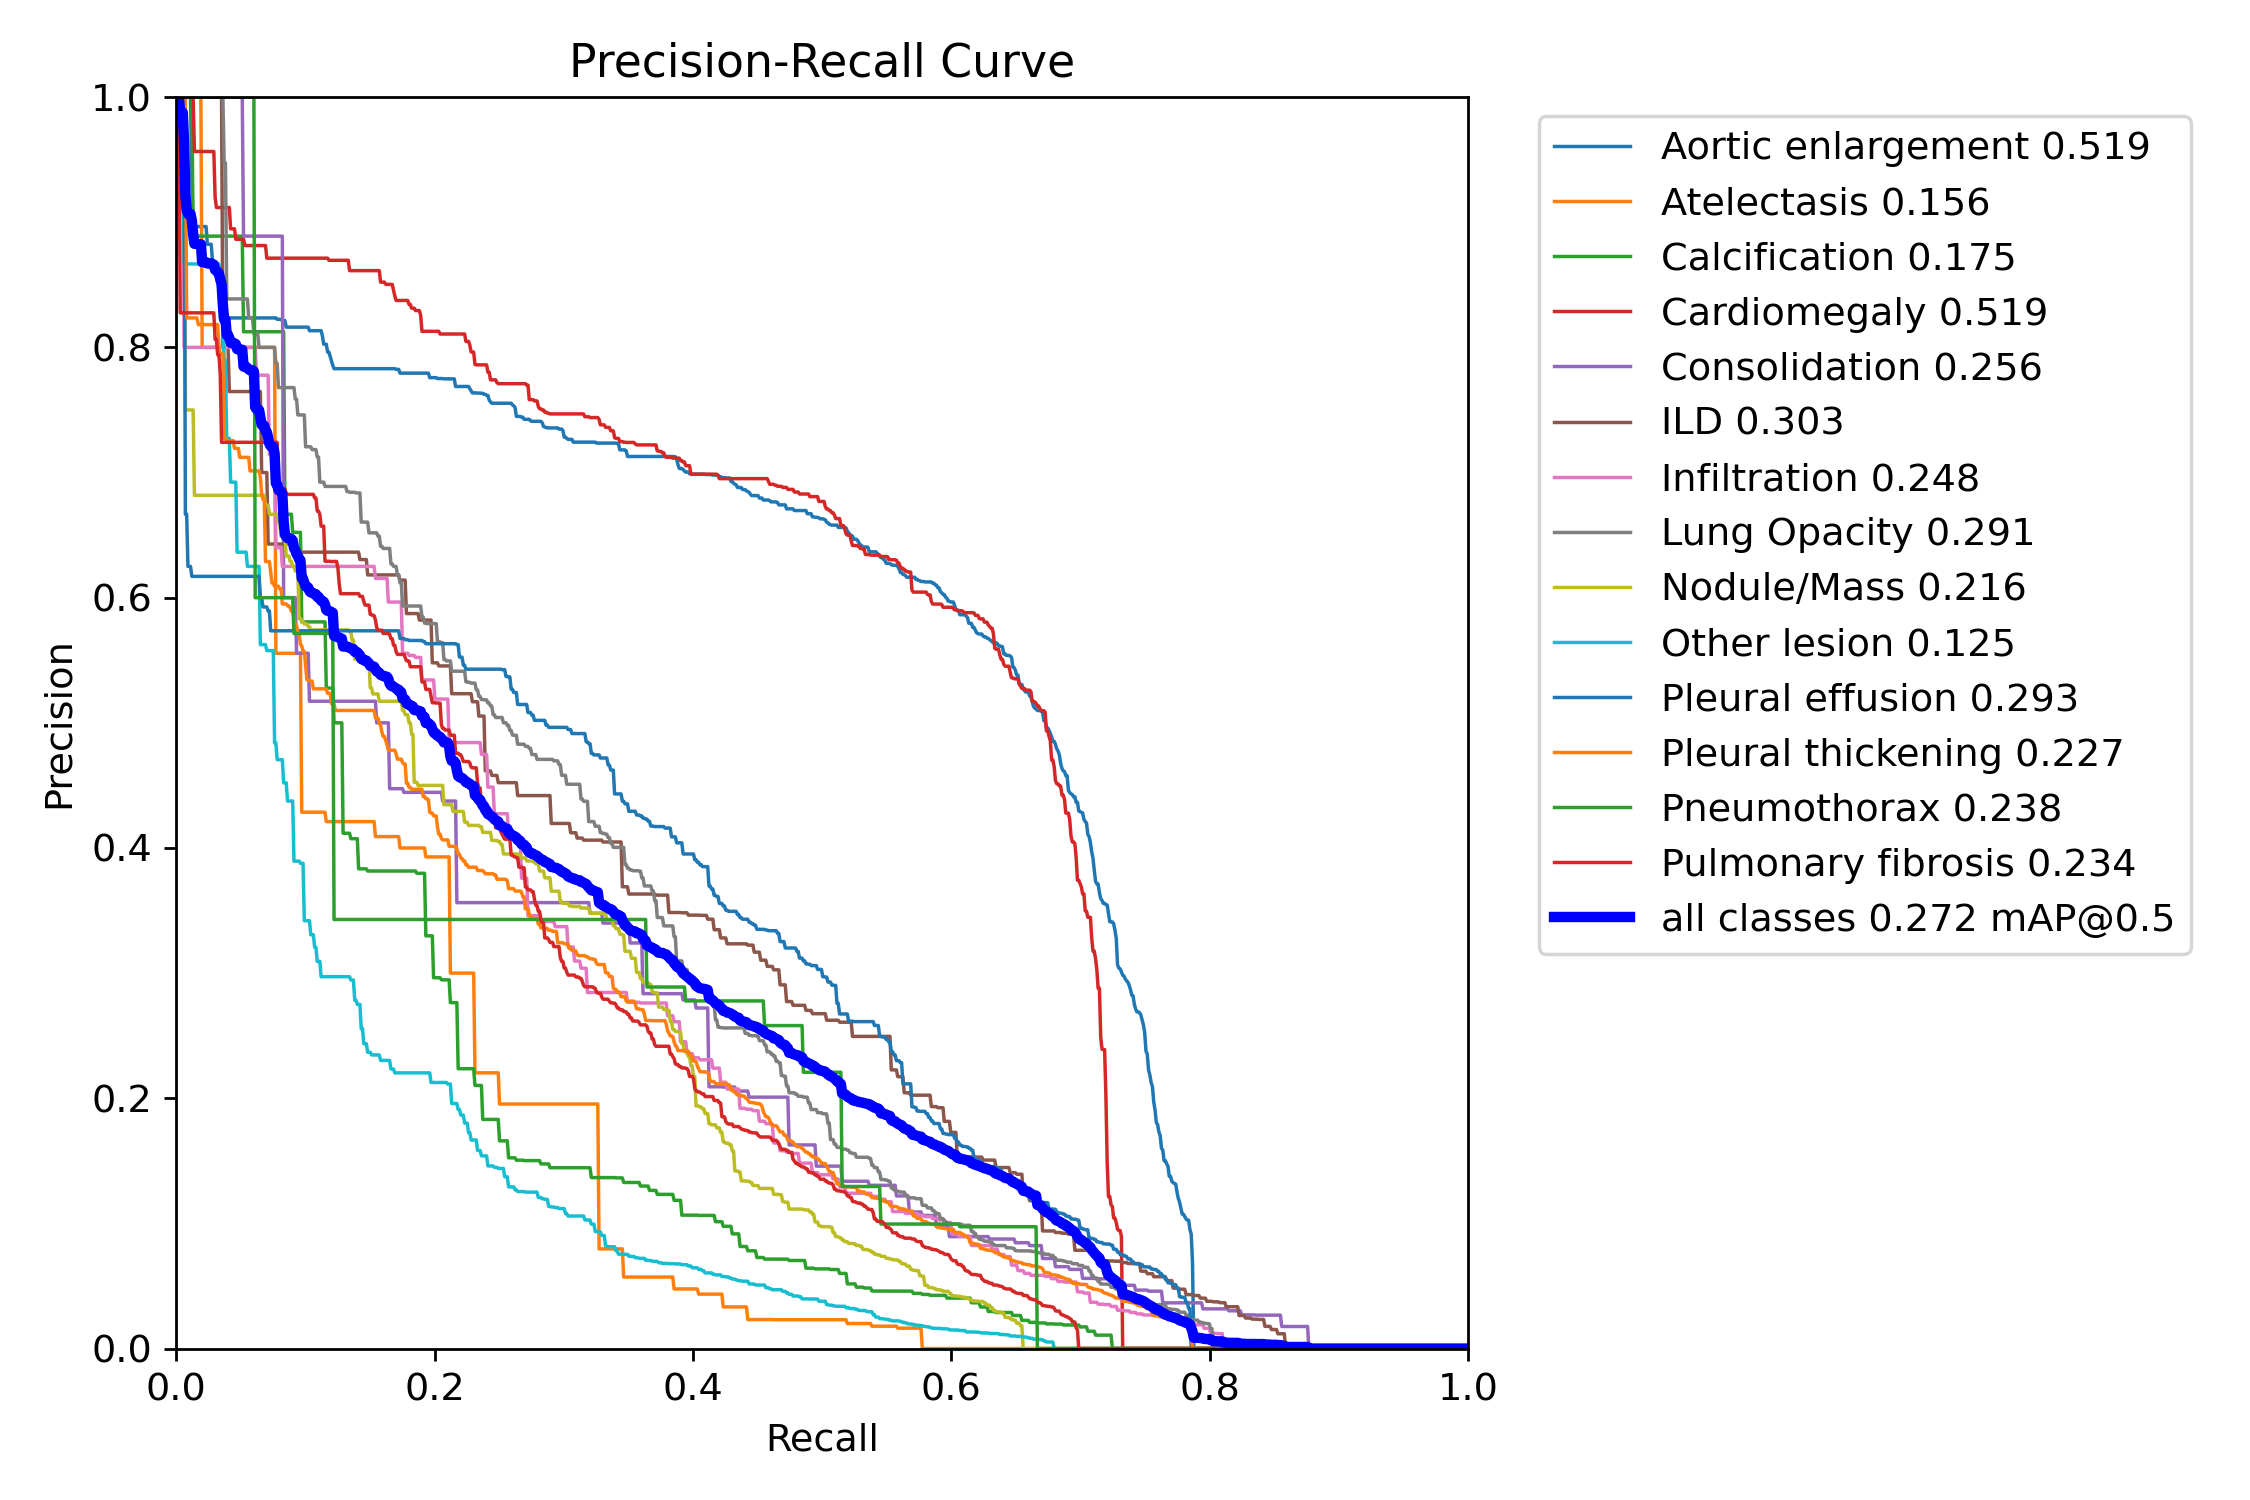

/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/BoxF1_curve.png


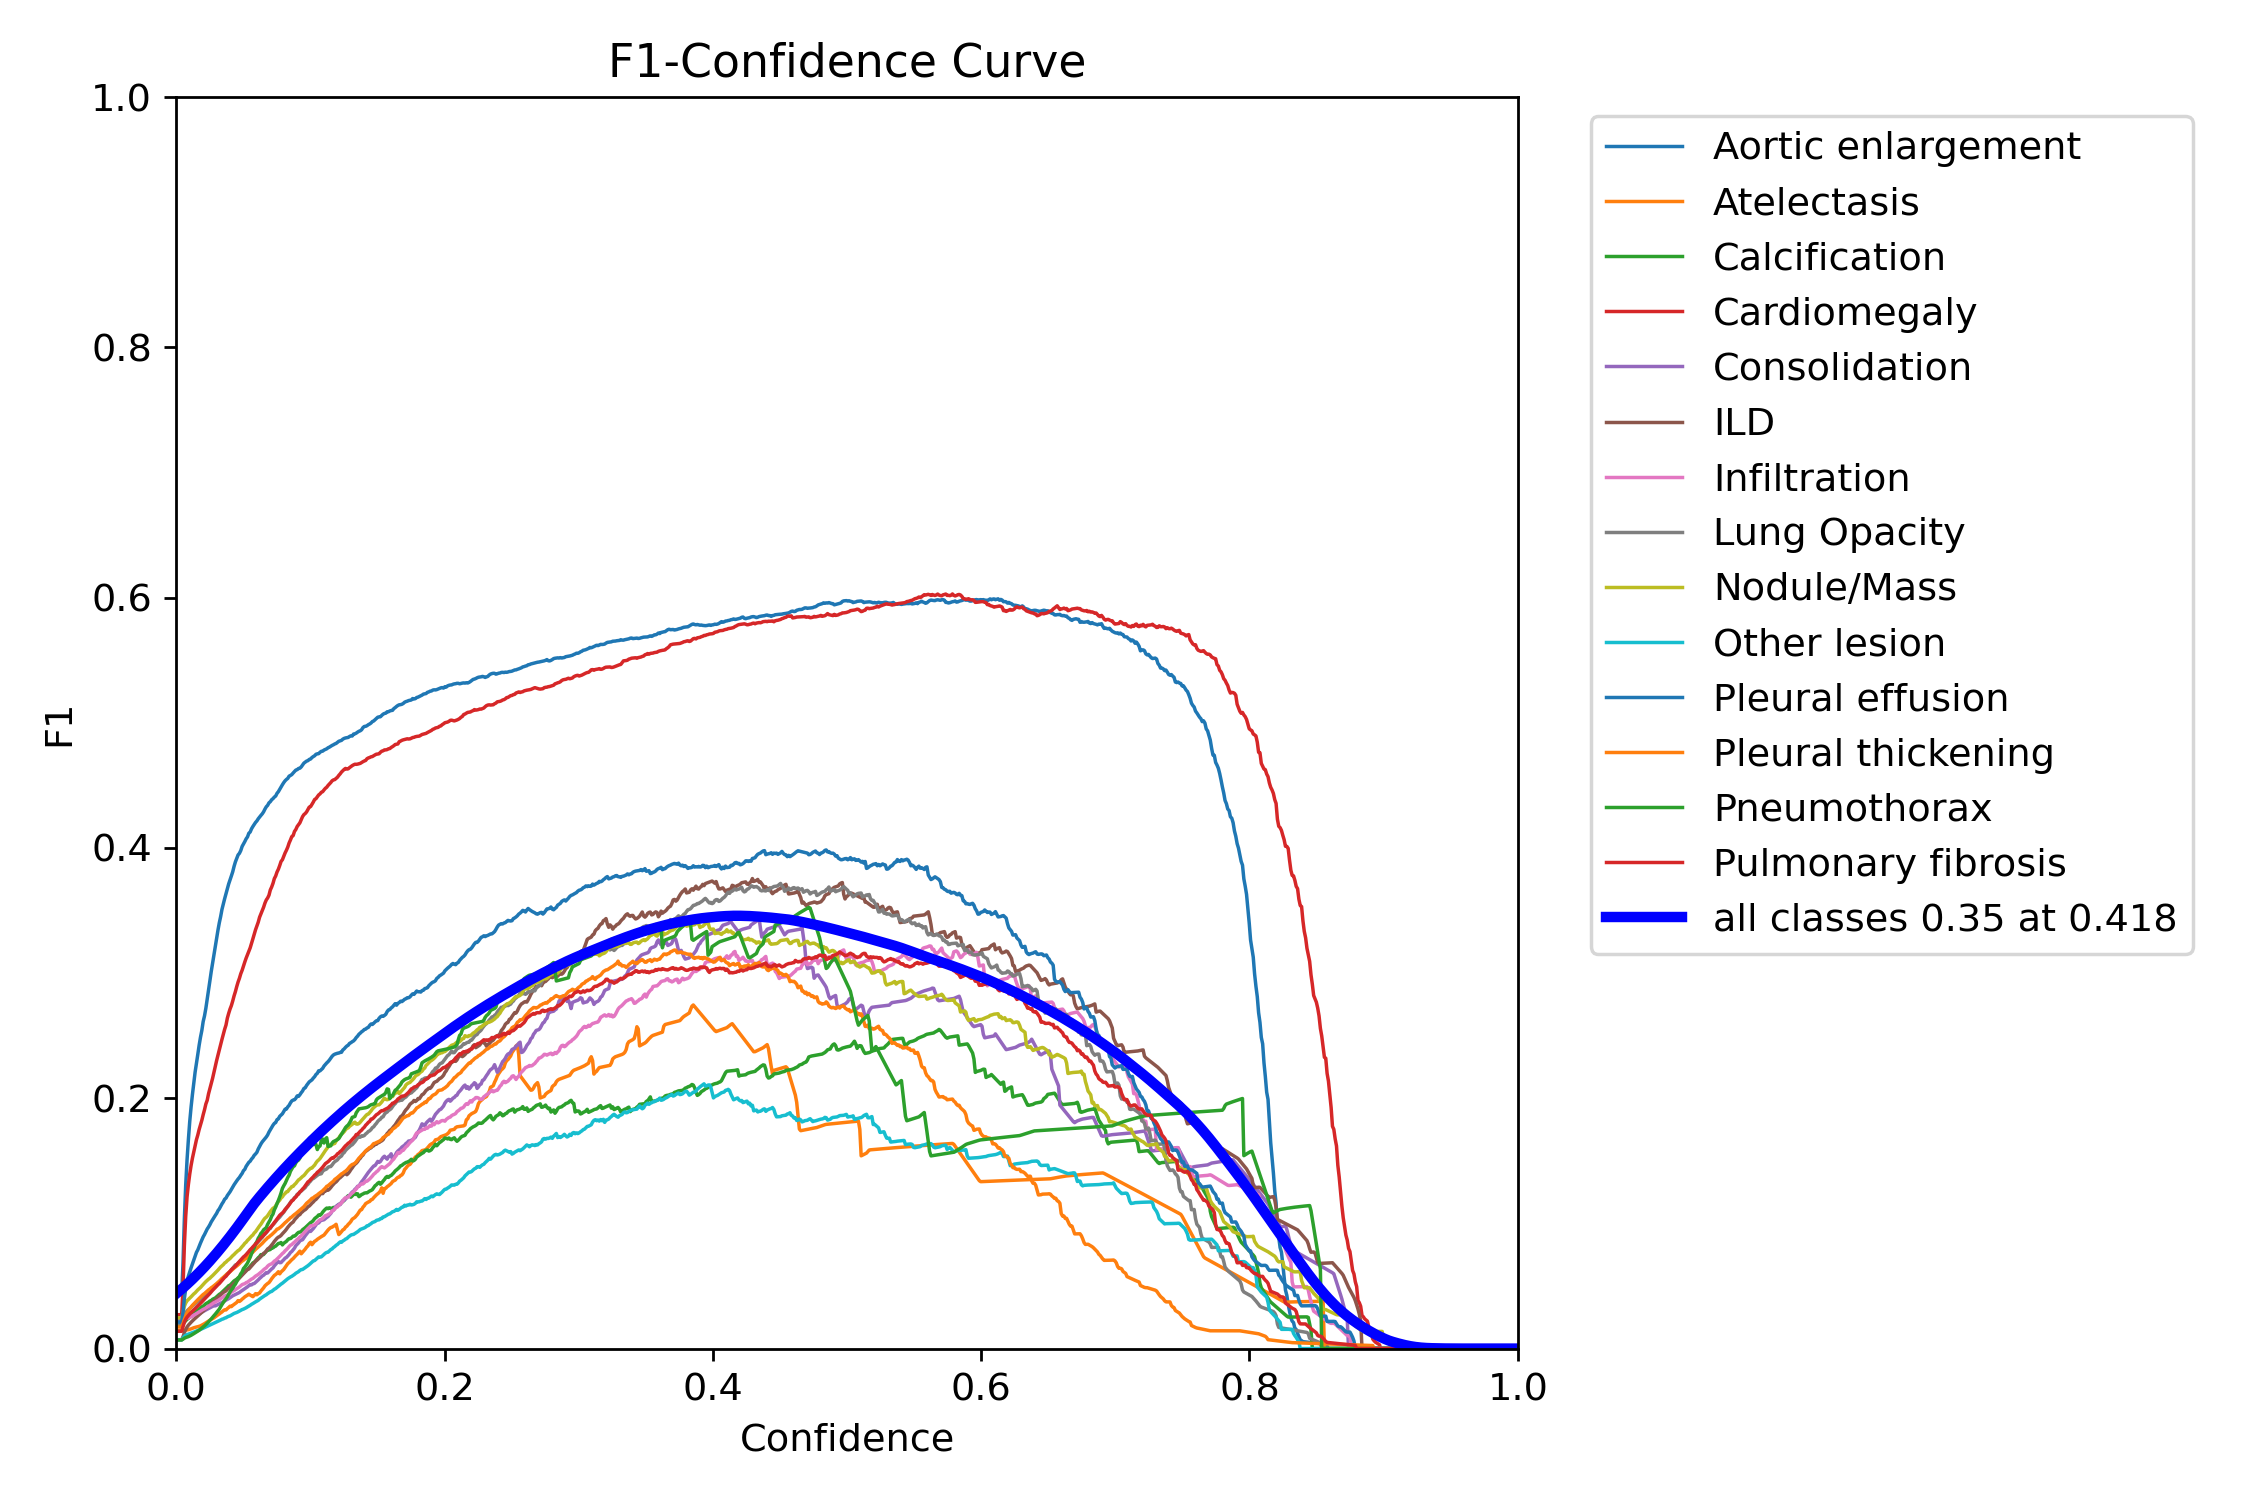

/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/confusion_matrix_normalized.png


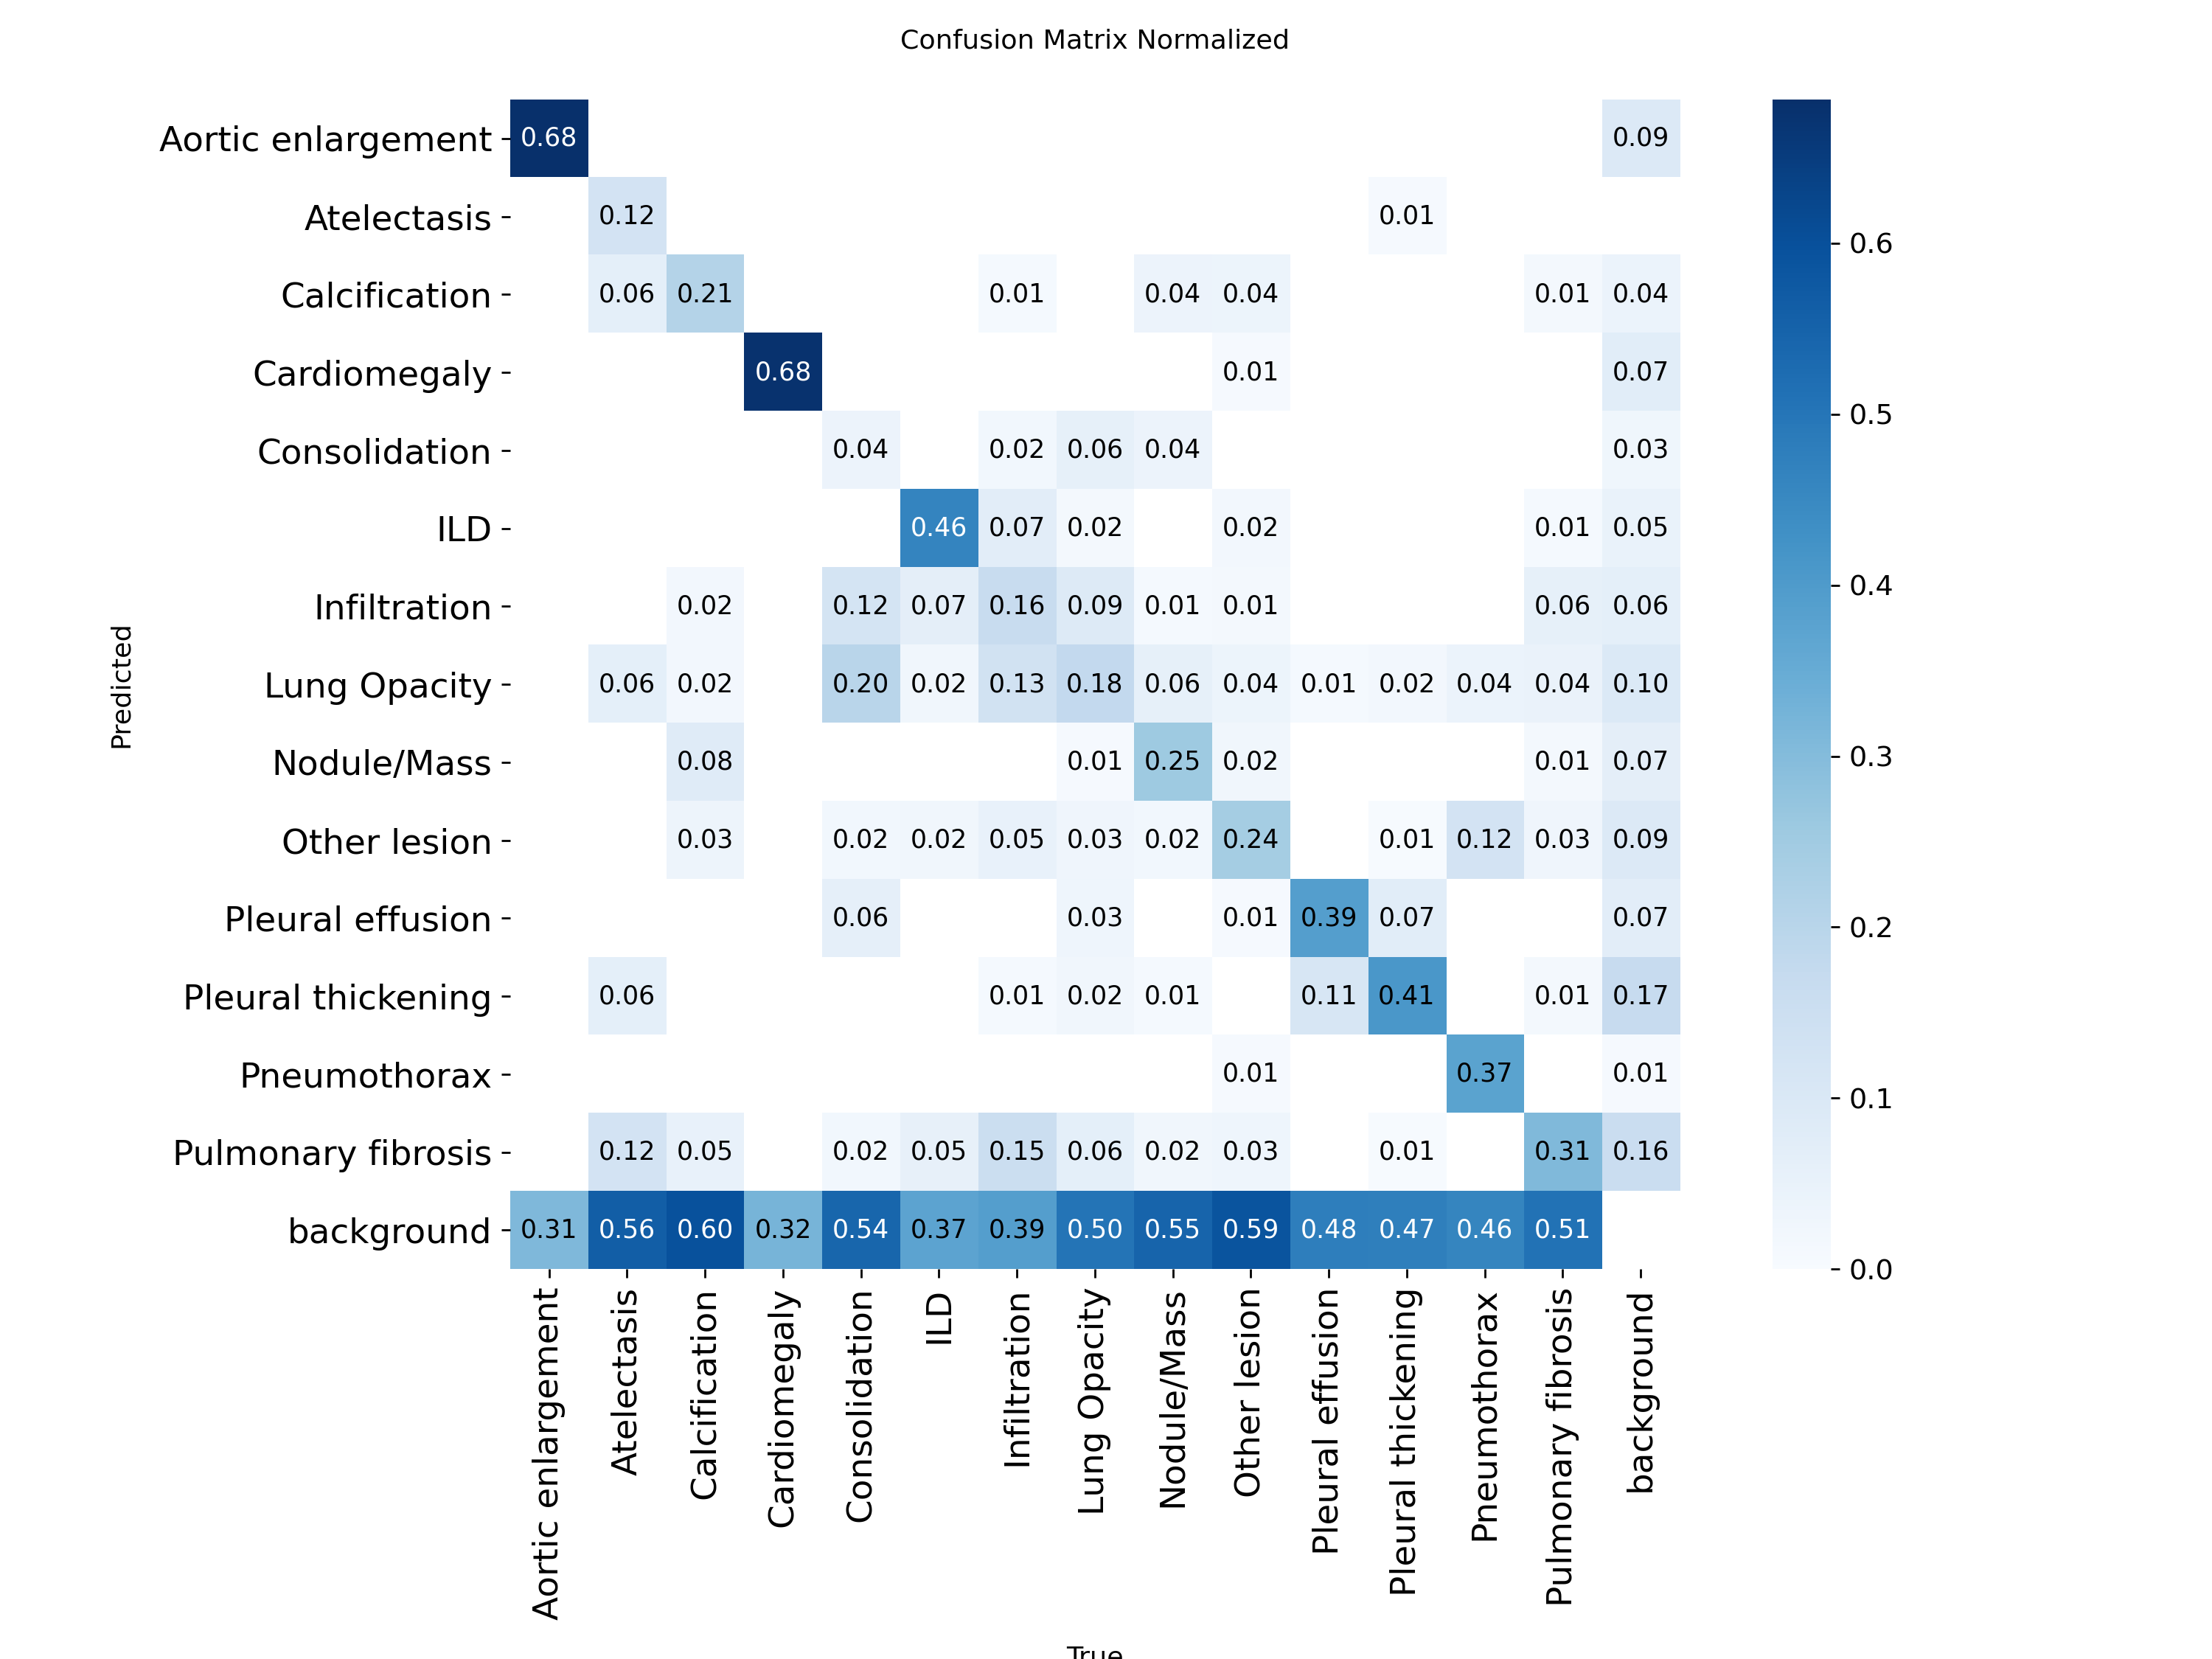

In [35]:
def show_artifact(relative_name: str, width: int = 900) -> None:
    path = RUN_DIR / relative_name
    if not path.exists():
        print(f"Missing artifact: {path}")
        return
    print(path)
    display(Image(filename=str(path), width=width))

for artifact in [
    "labels.jpg",
    "results.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "confusion_matrix_normalized.png",
]:
    show_artifact(artifact)


## 2.14. Qualitative model showcase: labels versus predictions

The validation-batch images below are the most direct local showcase of the trained detector. For each batch, the `*_labels.jpg` image shows ground-truth boxes and the `*_pred.jpg` image shows the model predictions produced by the trained run.


Validation batch 0: labels
/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/val_batch0_labels.jpg


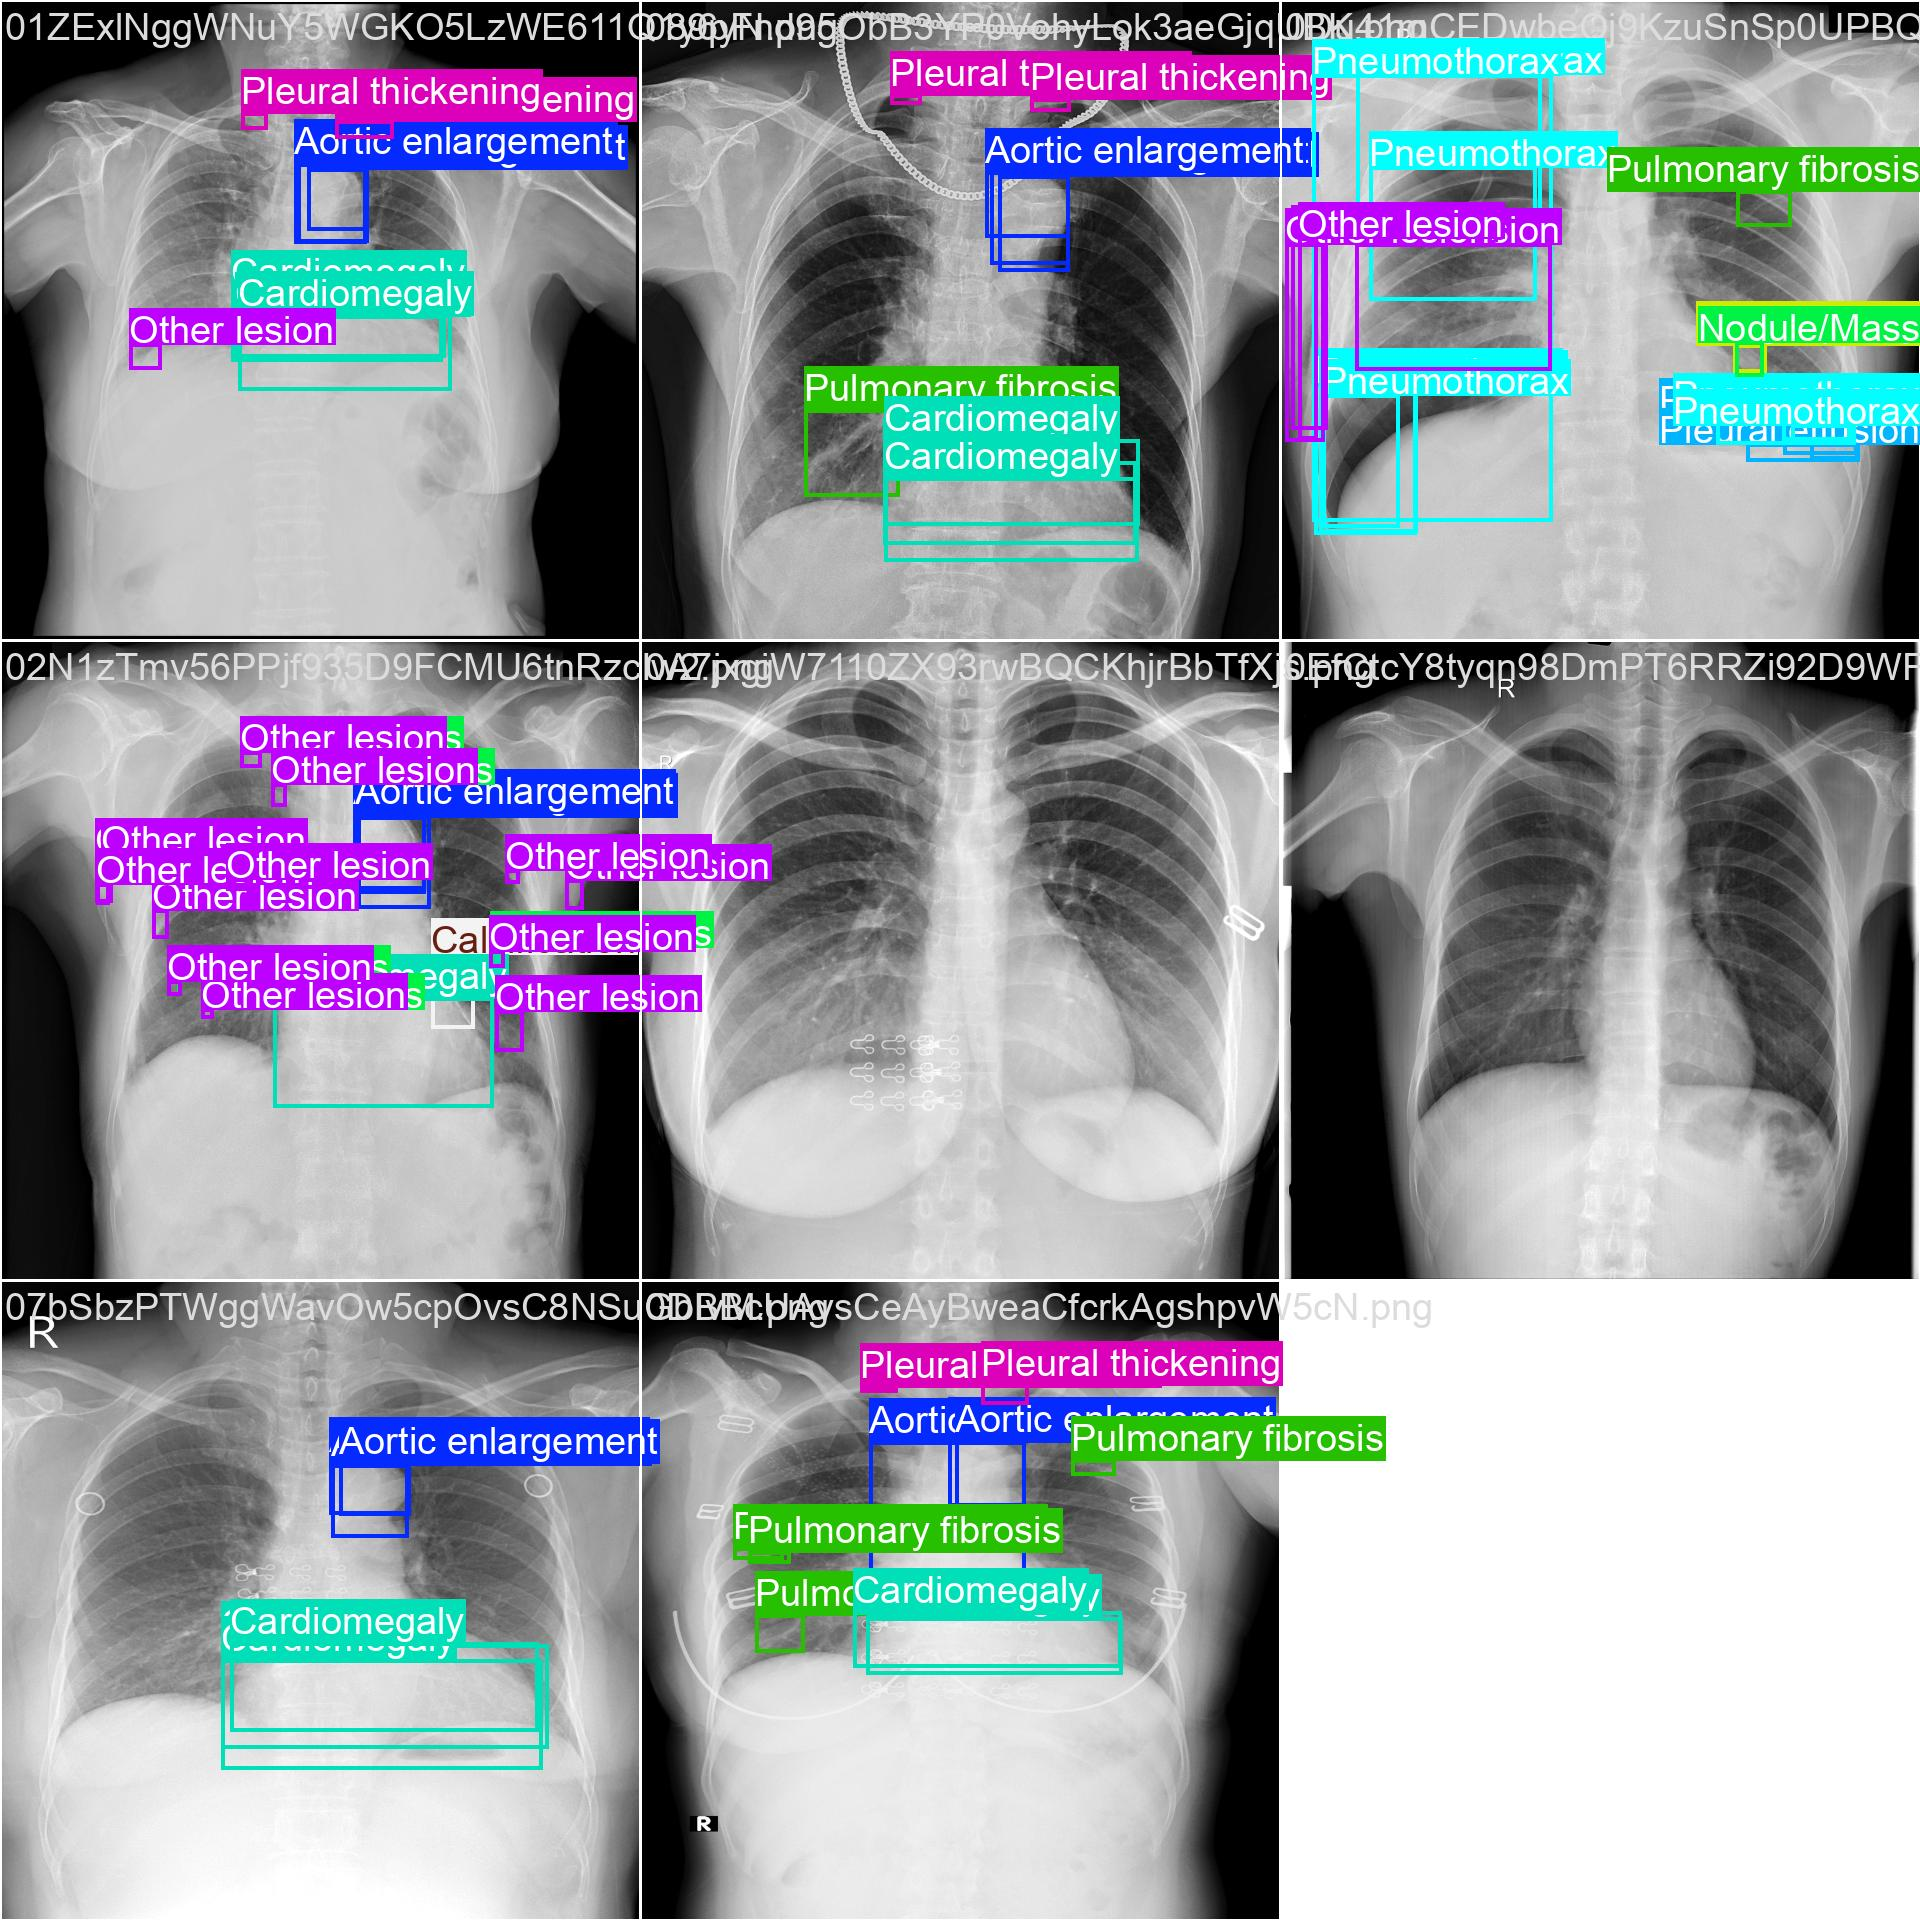

Validation batch 0: predictions
/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/val_batch0_pred.jpg


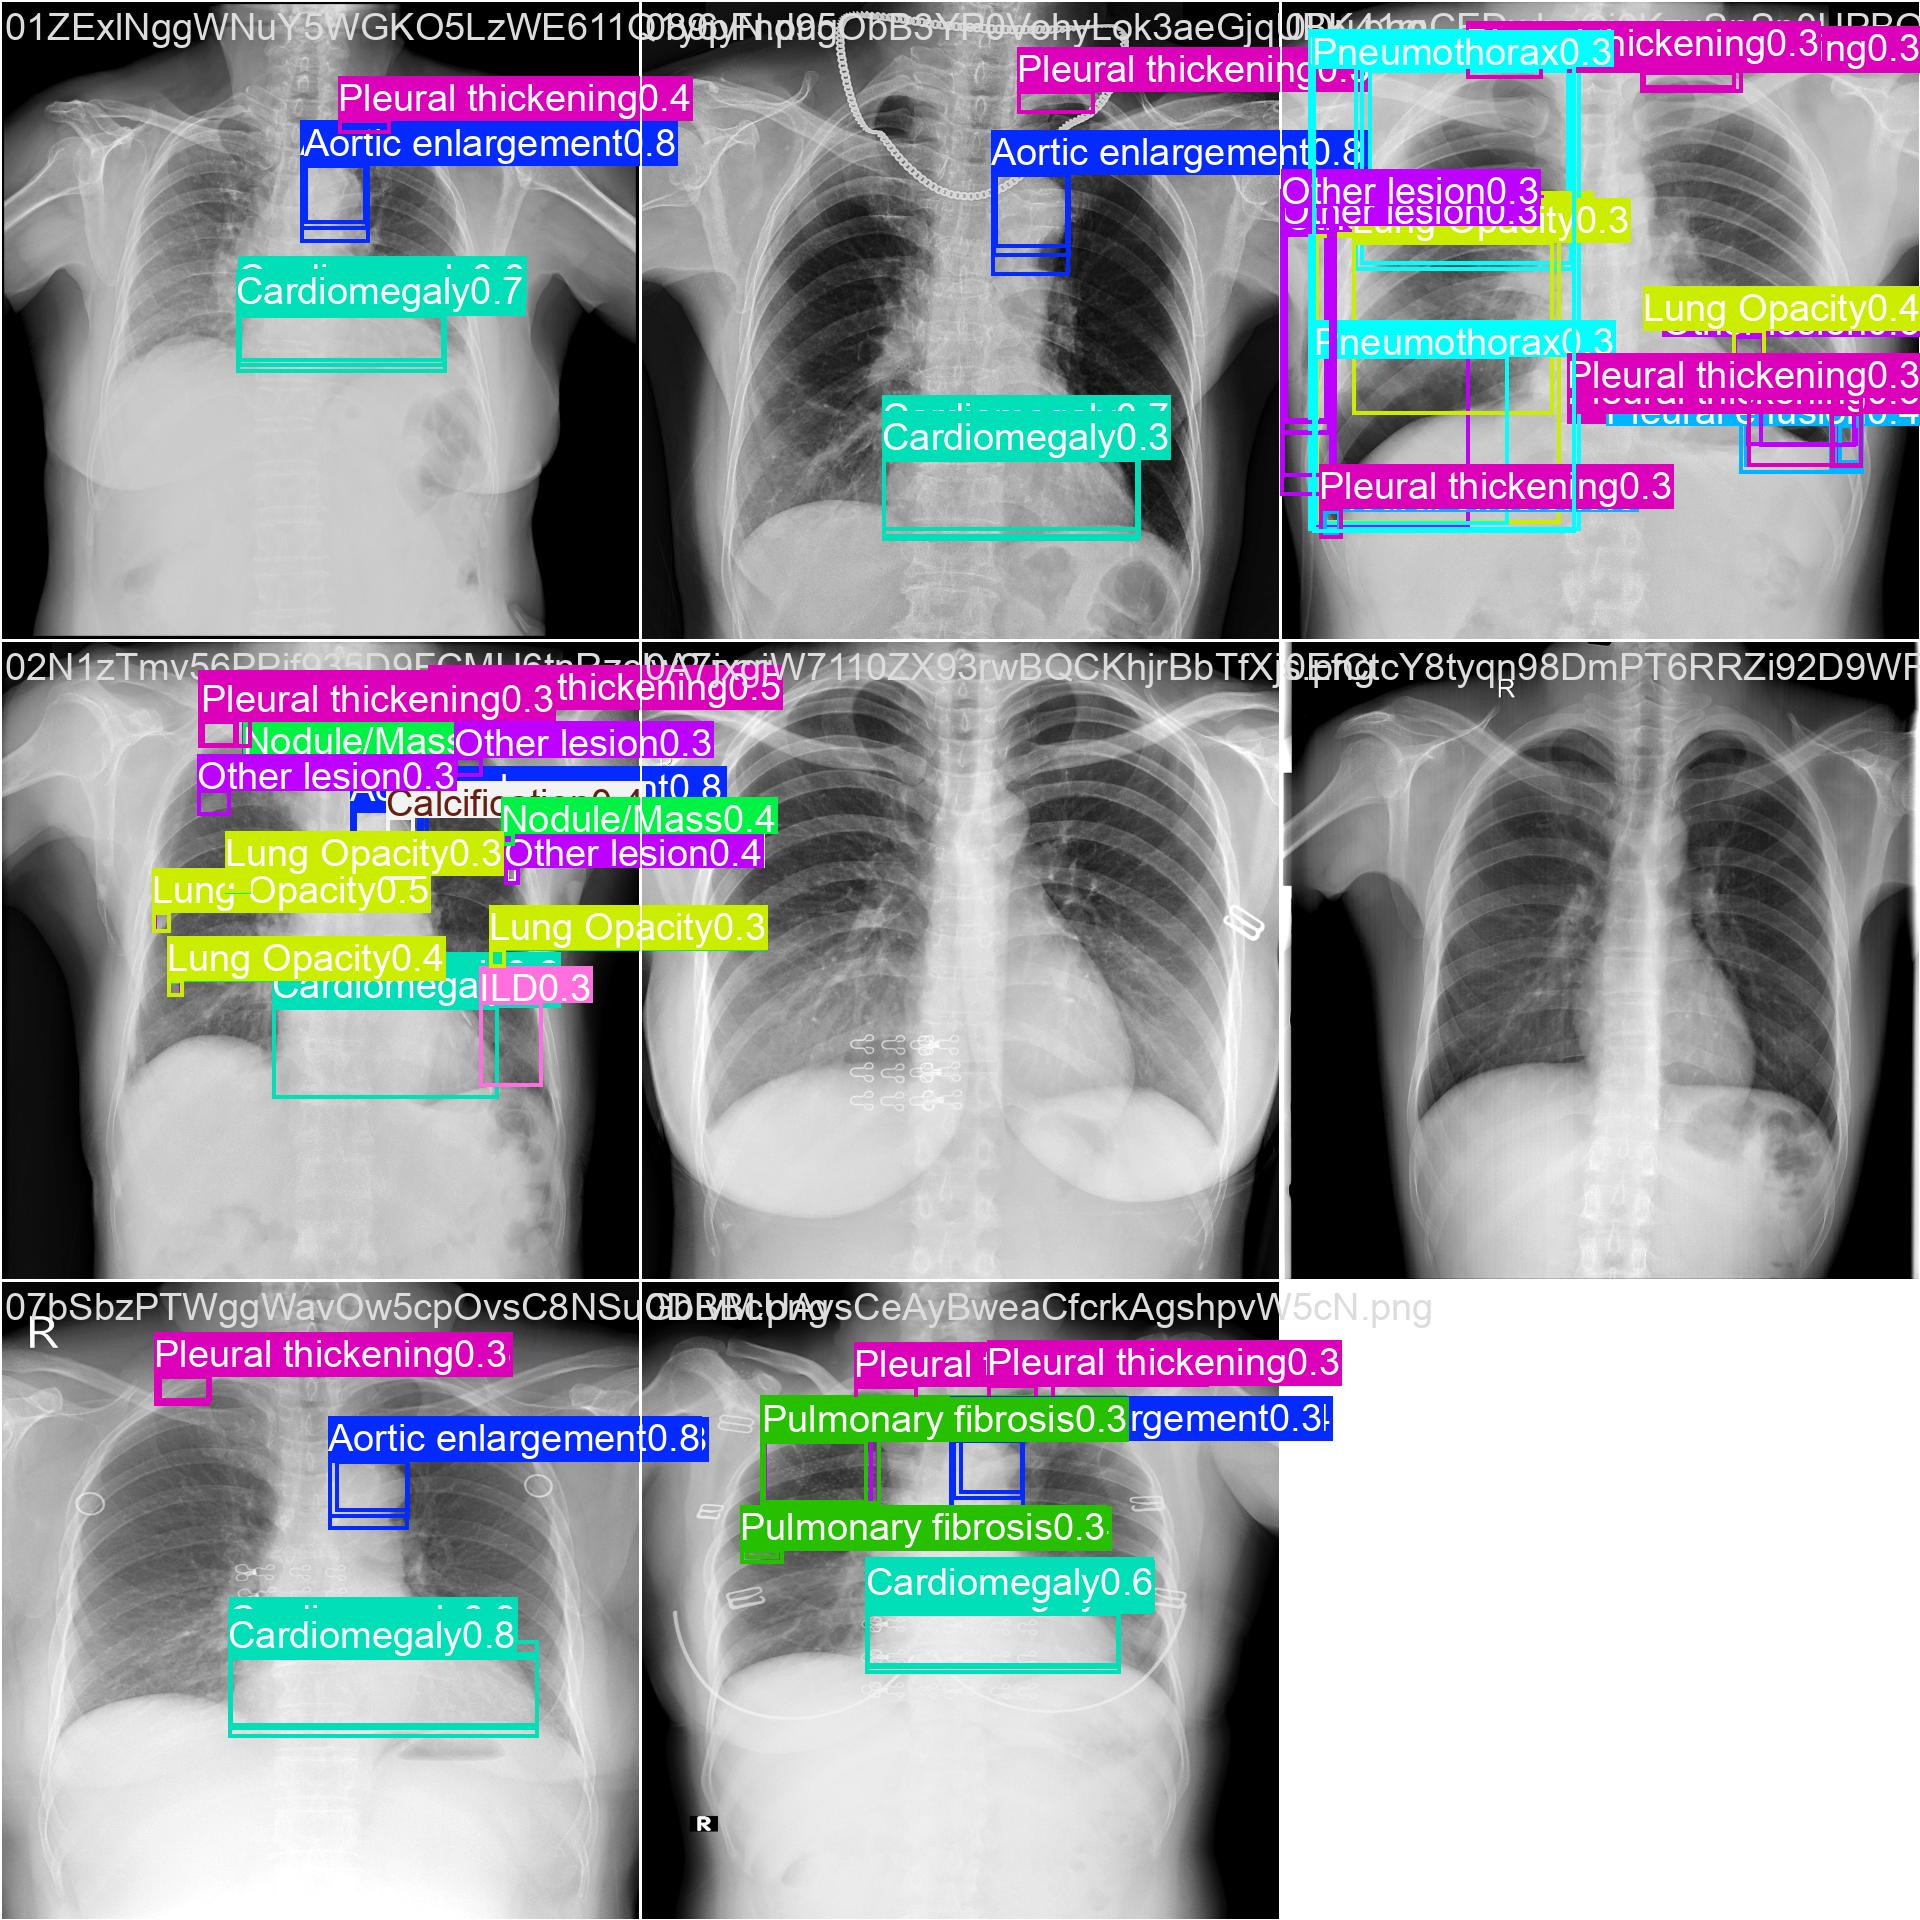

Validation batch 1: labels
/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/val_batch1_labels.jpg


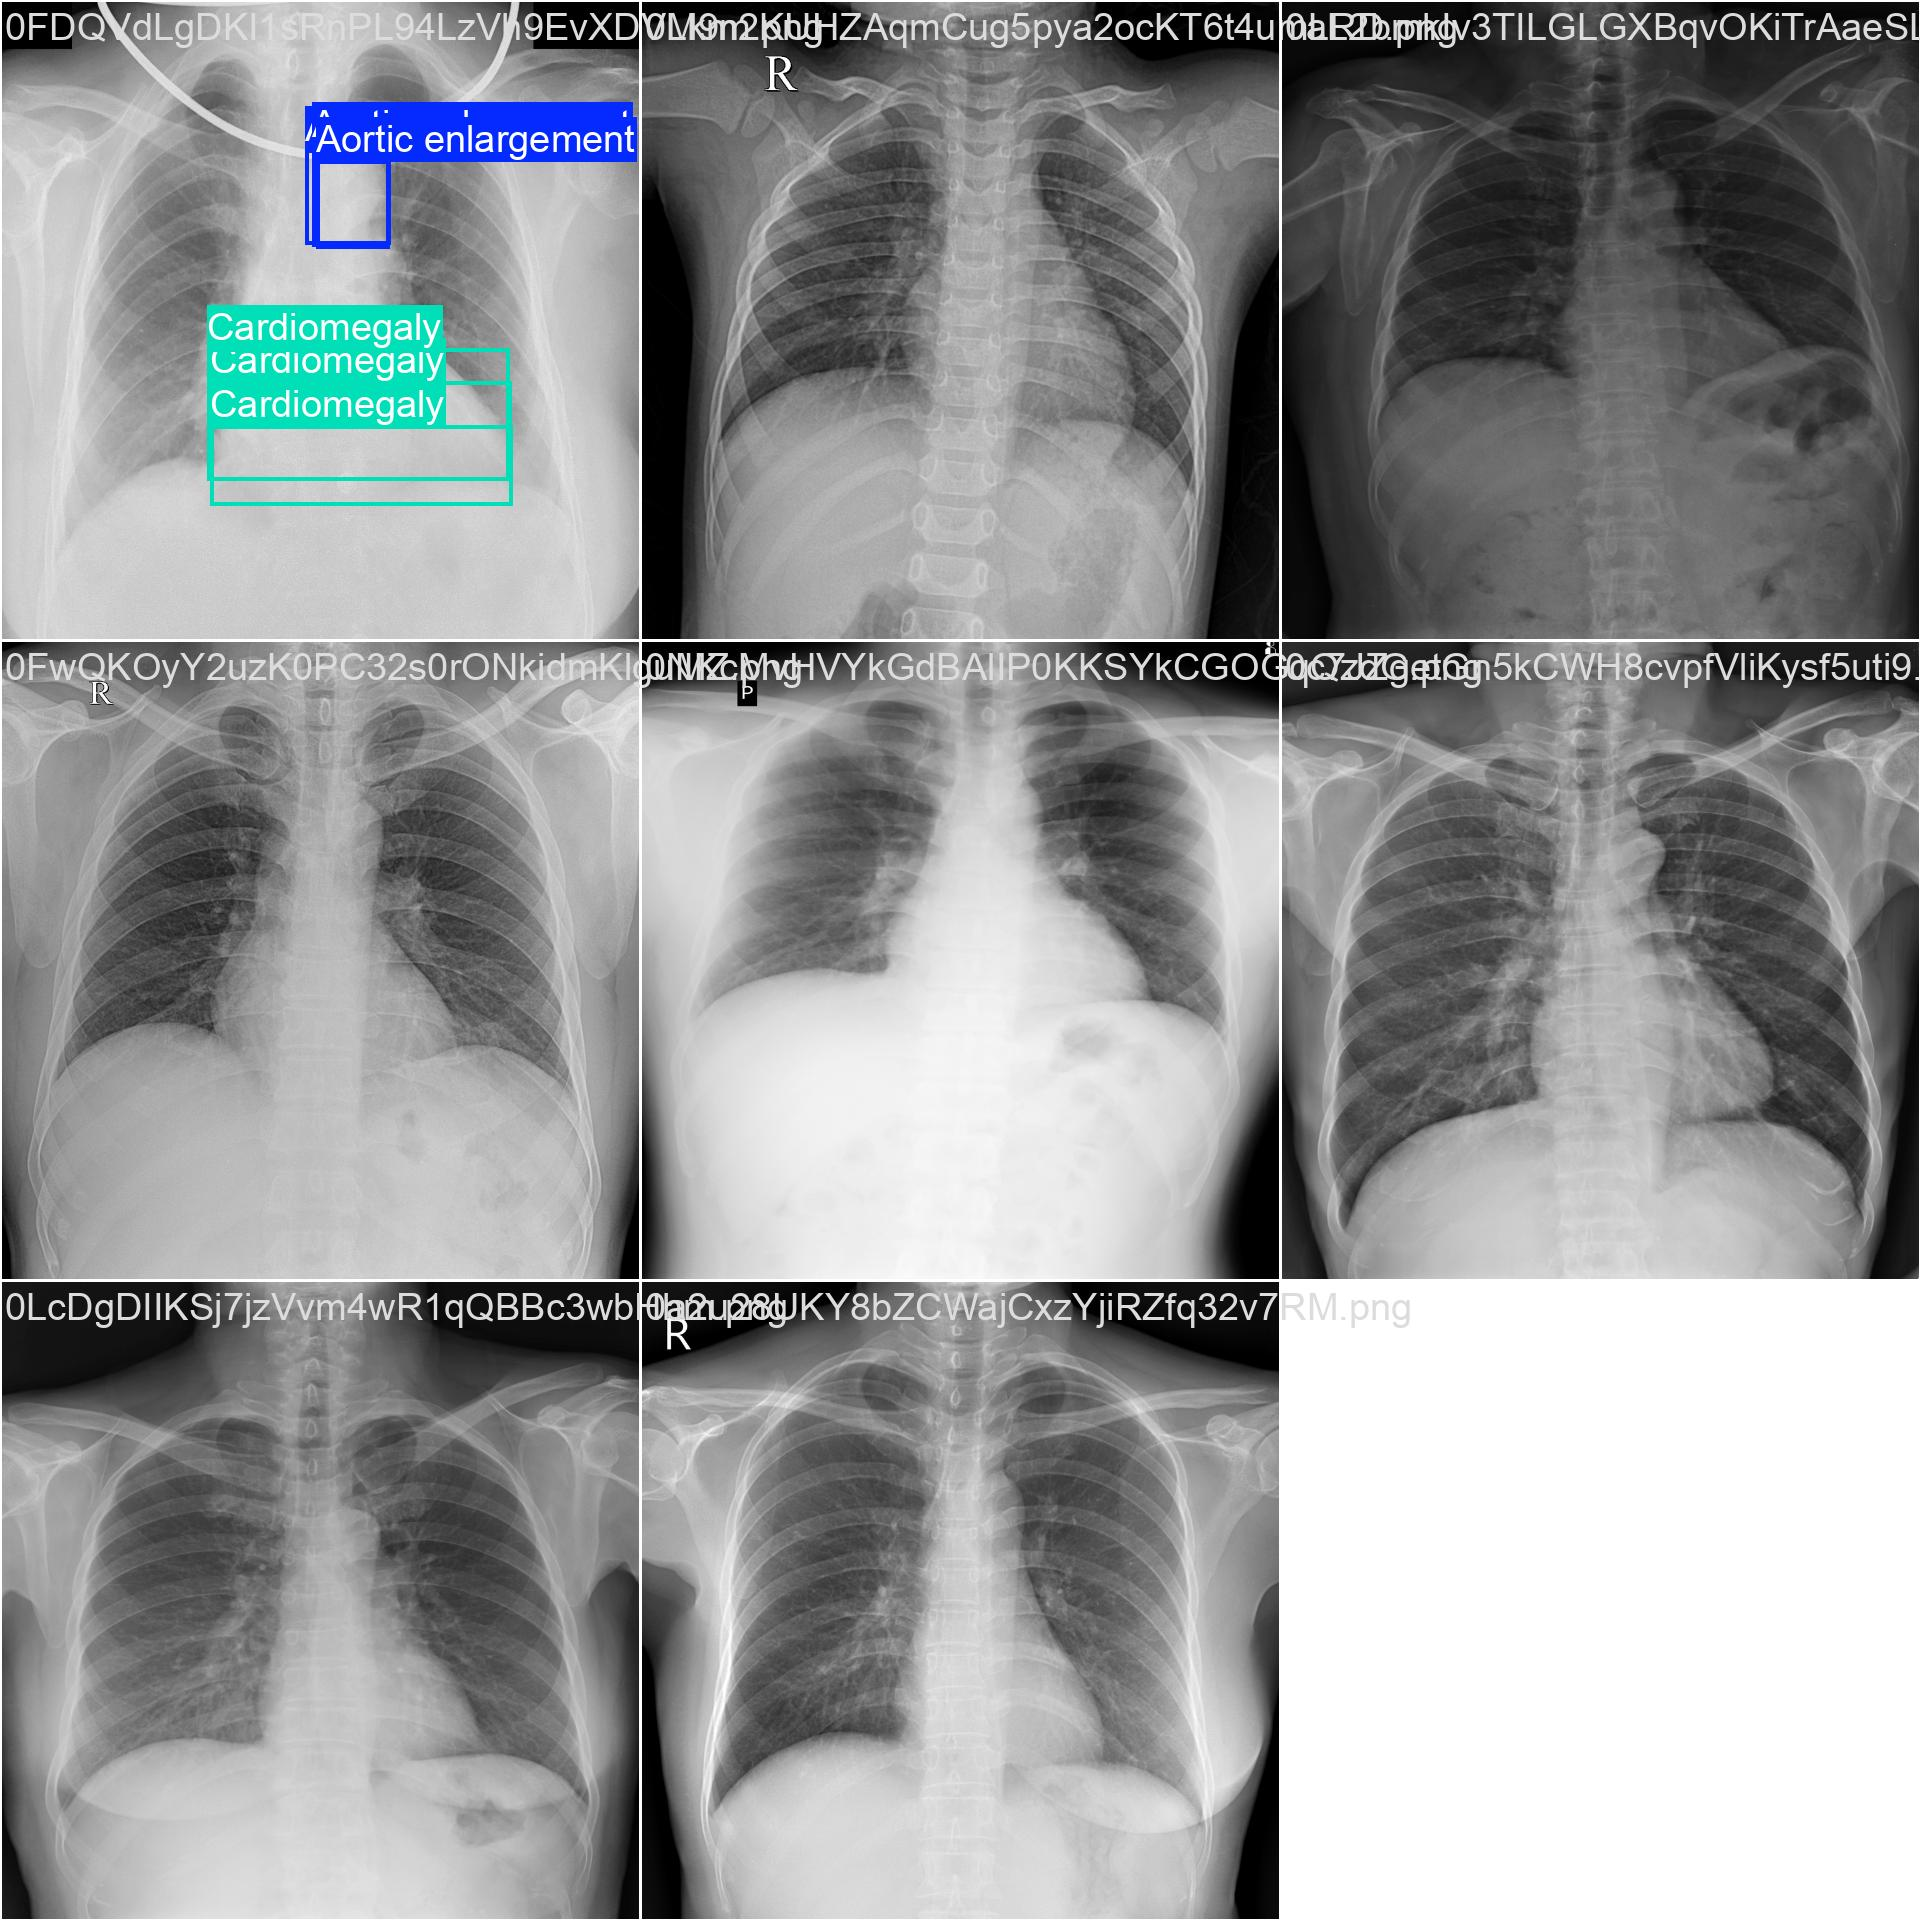

Validation batch 1: predictions
/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/val_batch1_pred.jpg


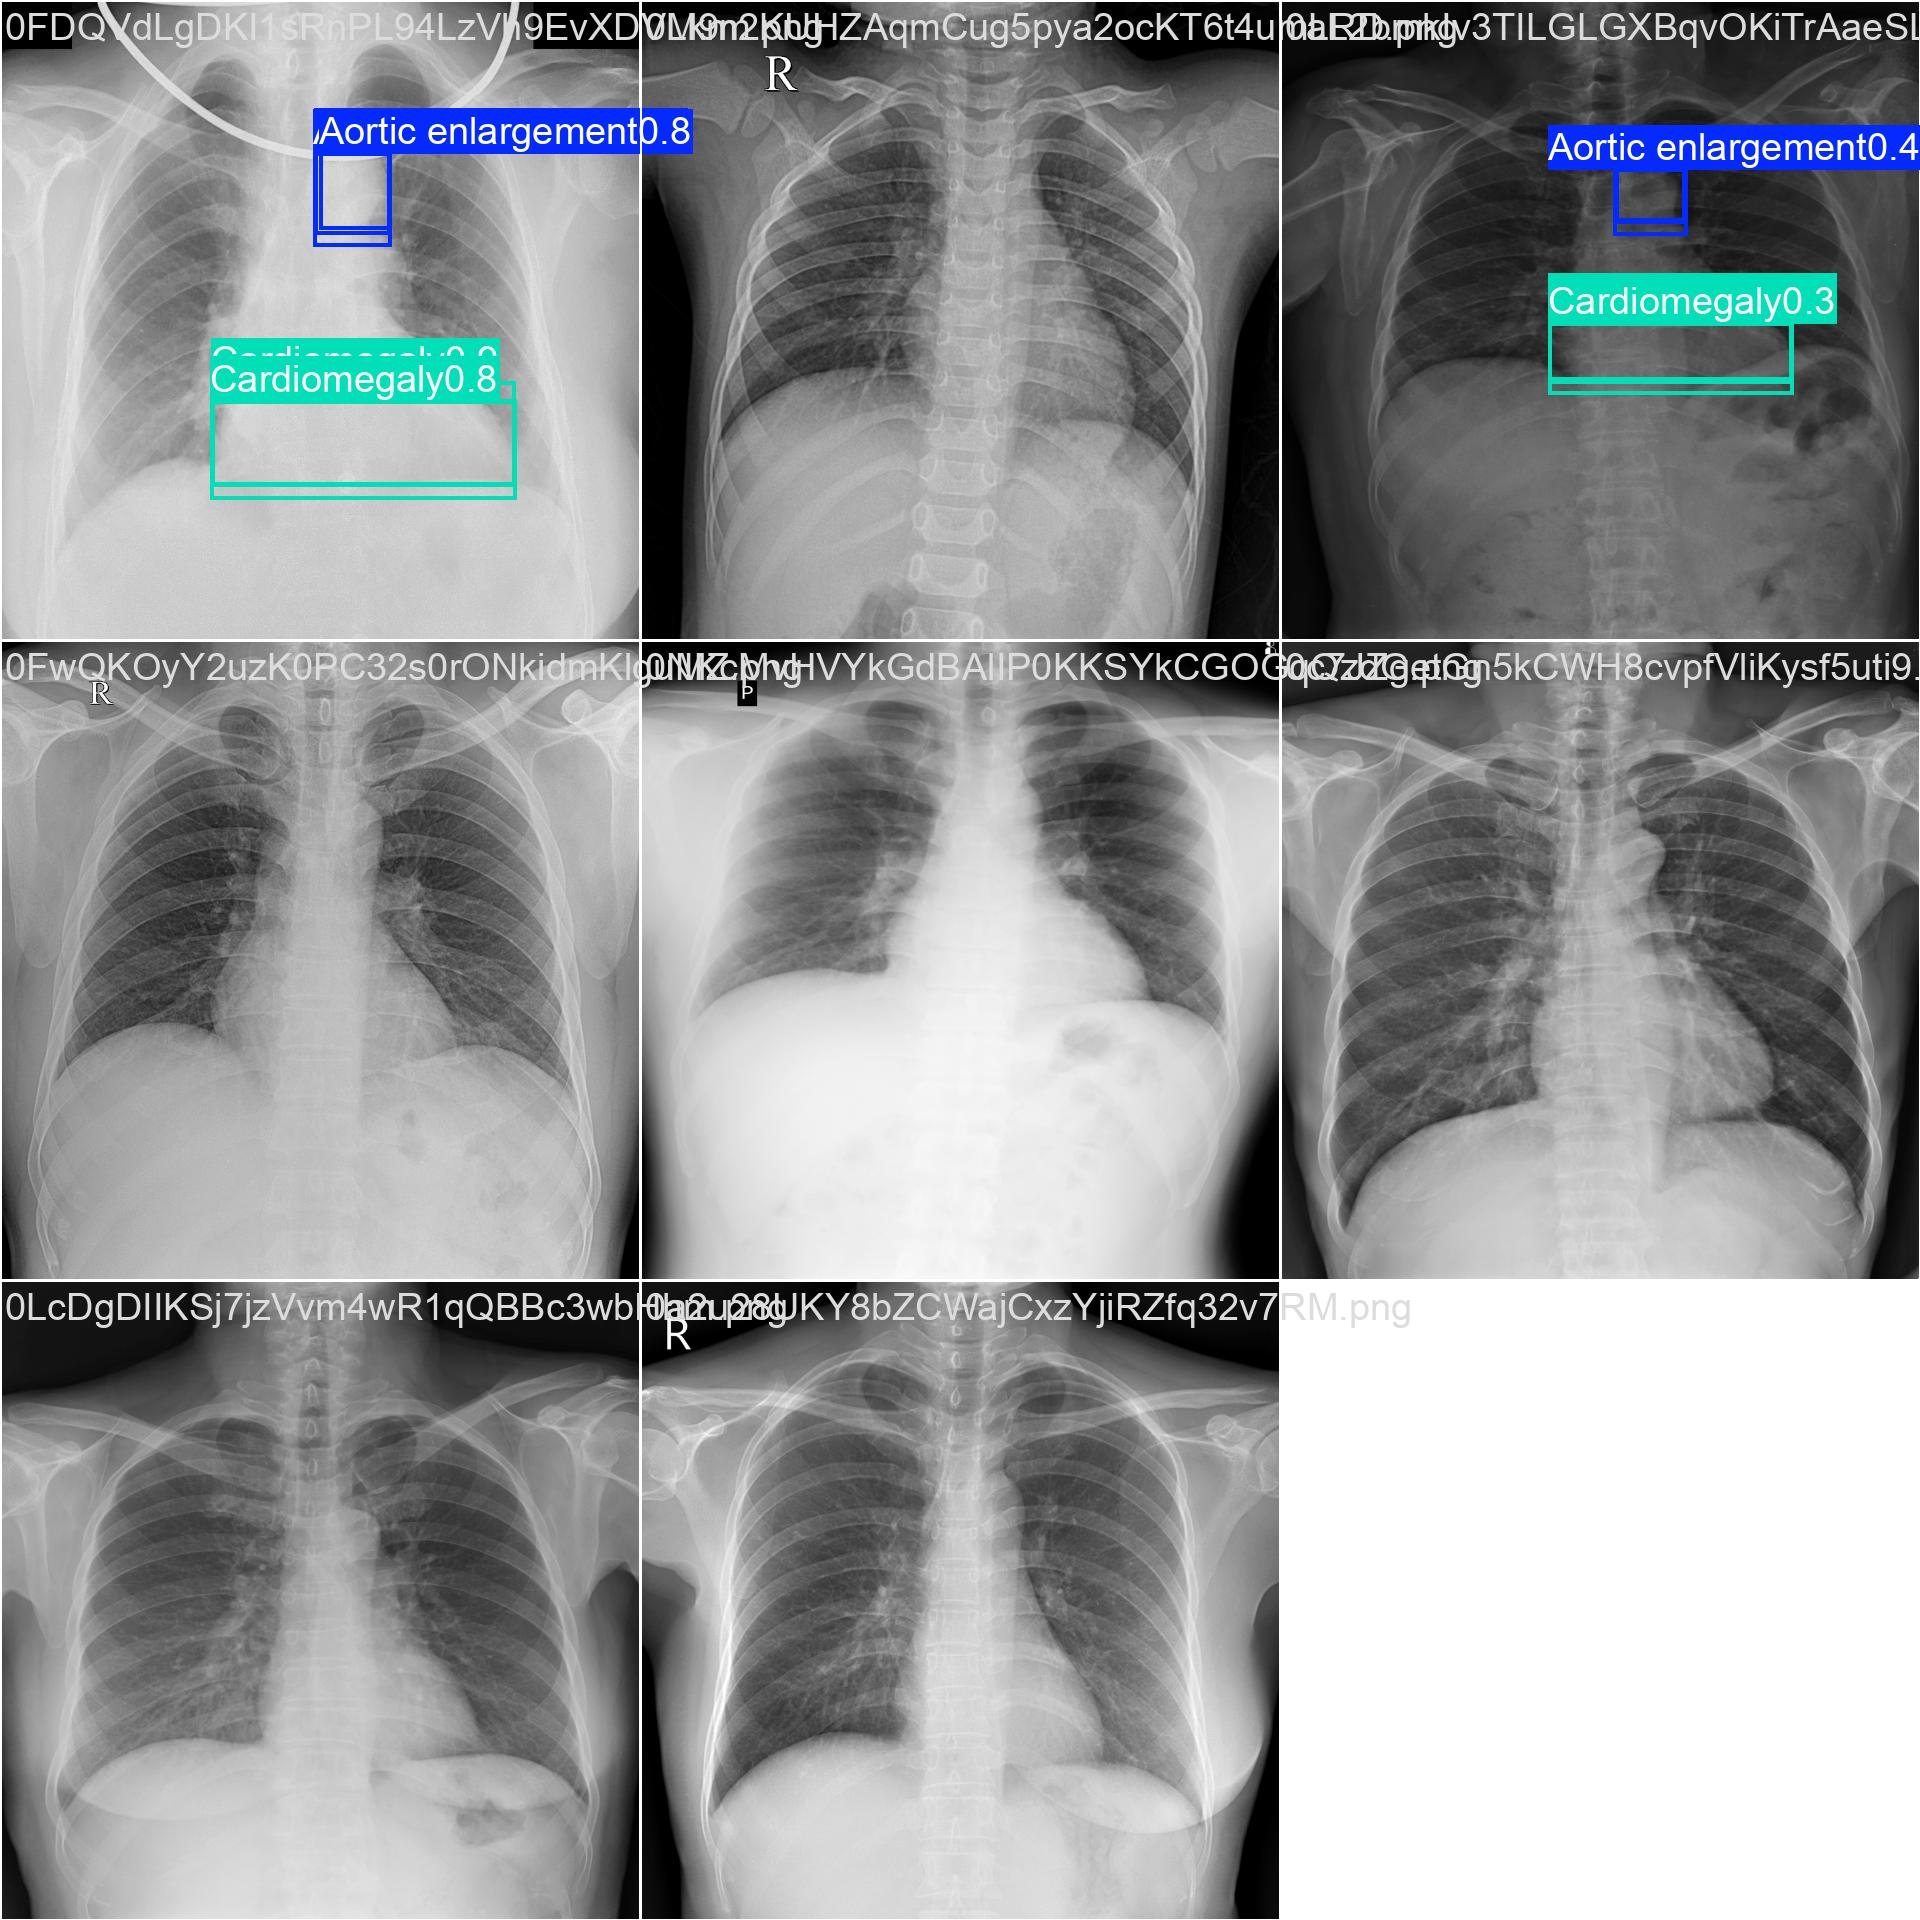

Validation batch 2: labels
/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/val_batch2_labels.jpg


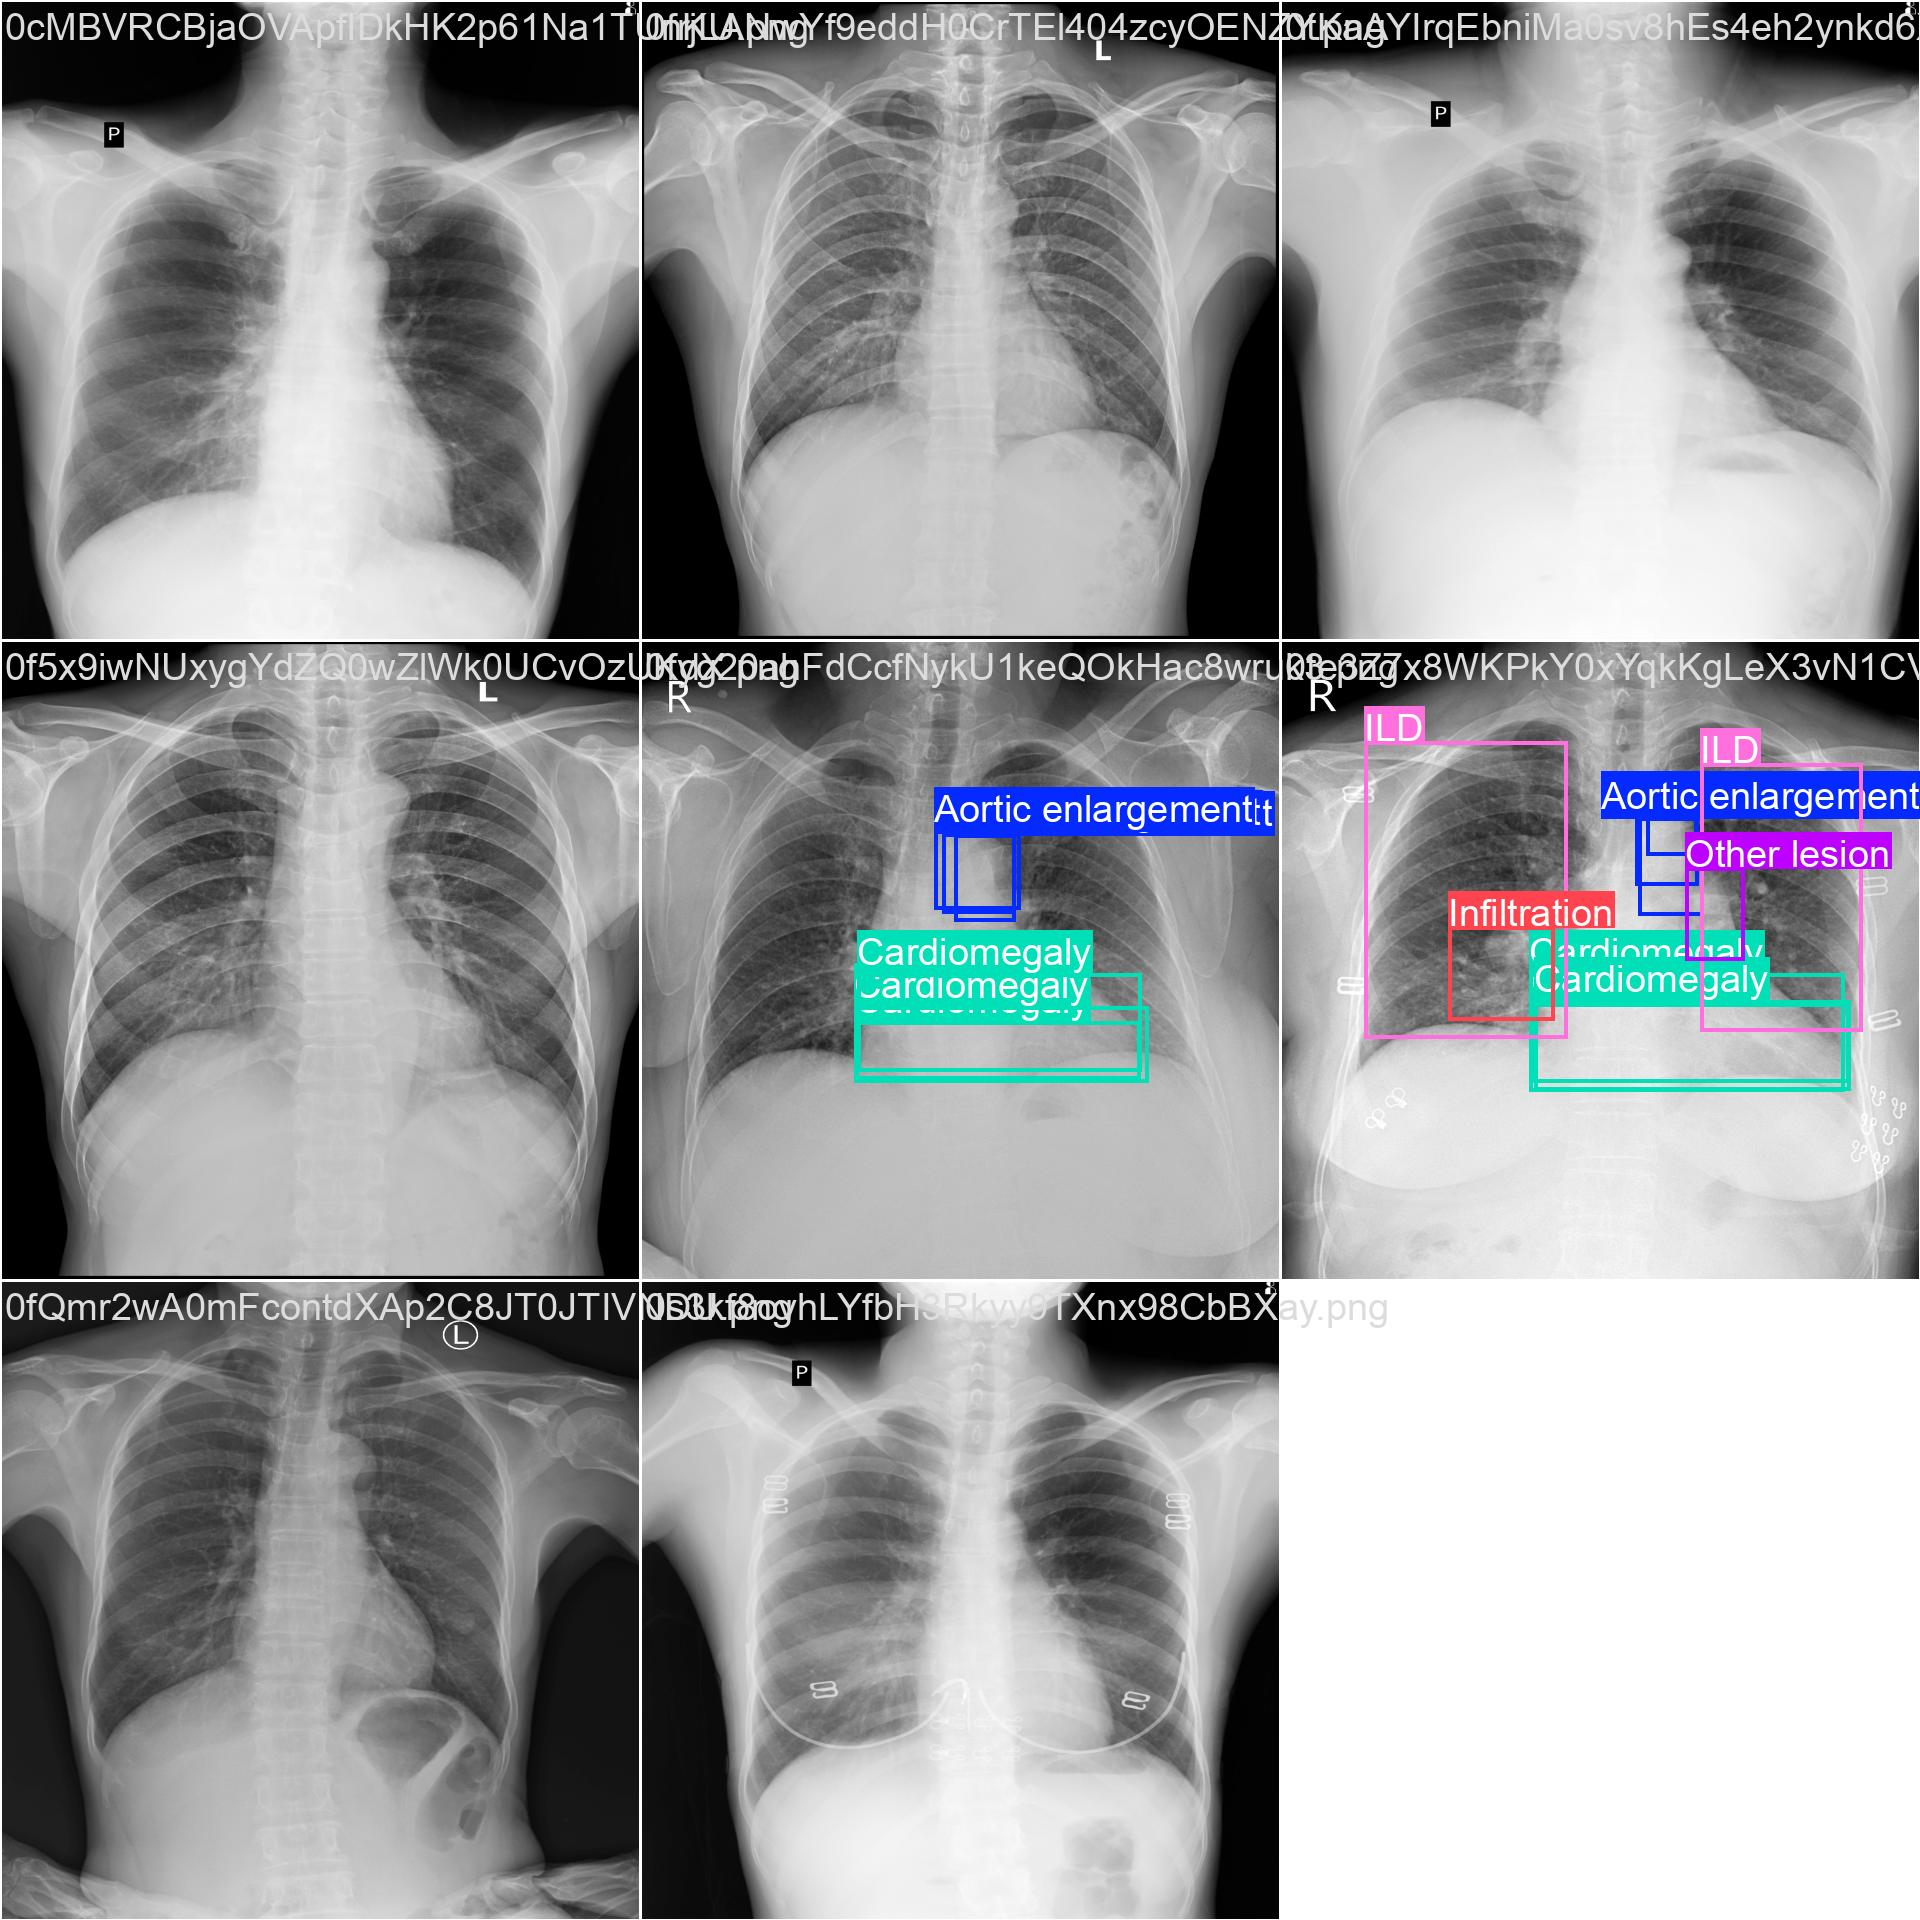

Validation batch 2: predictions
/home/mitin/code/ml-theory/midterms/02/kaggle/output/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/val_batch2_pred.jpg


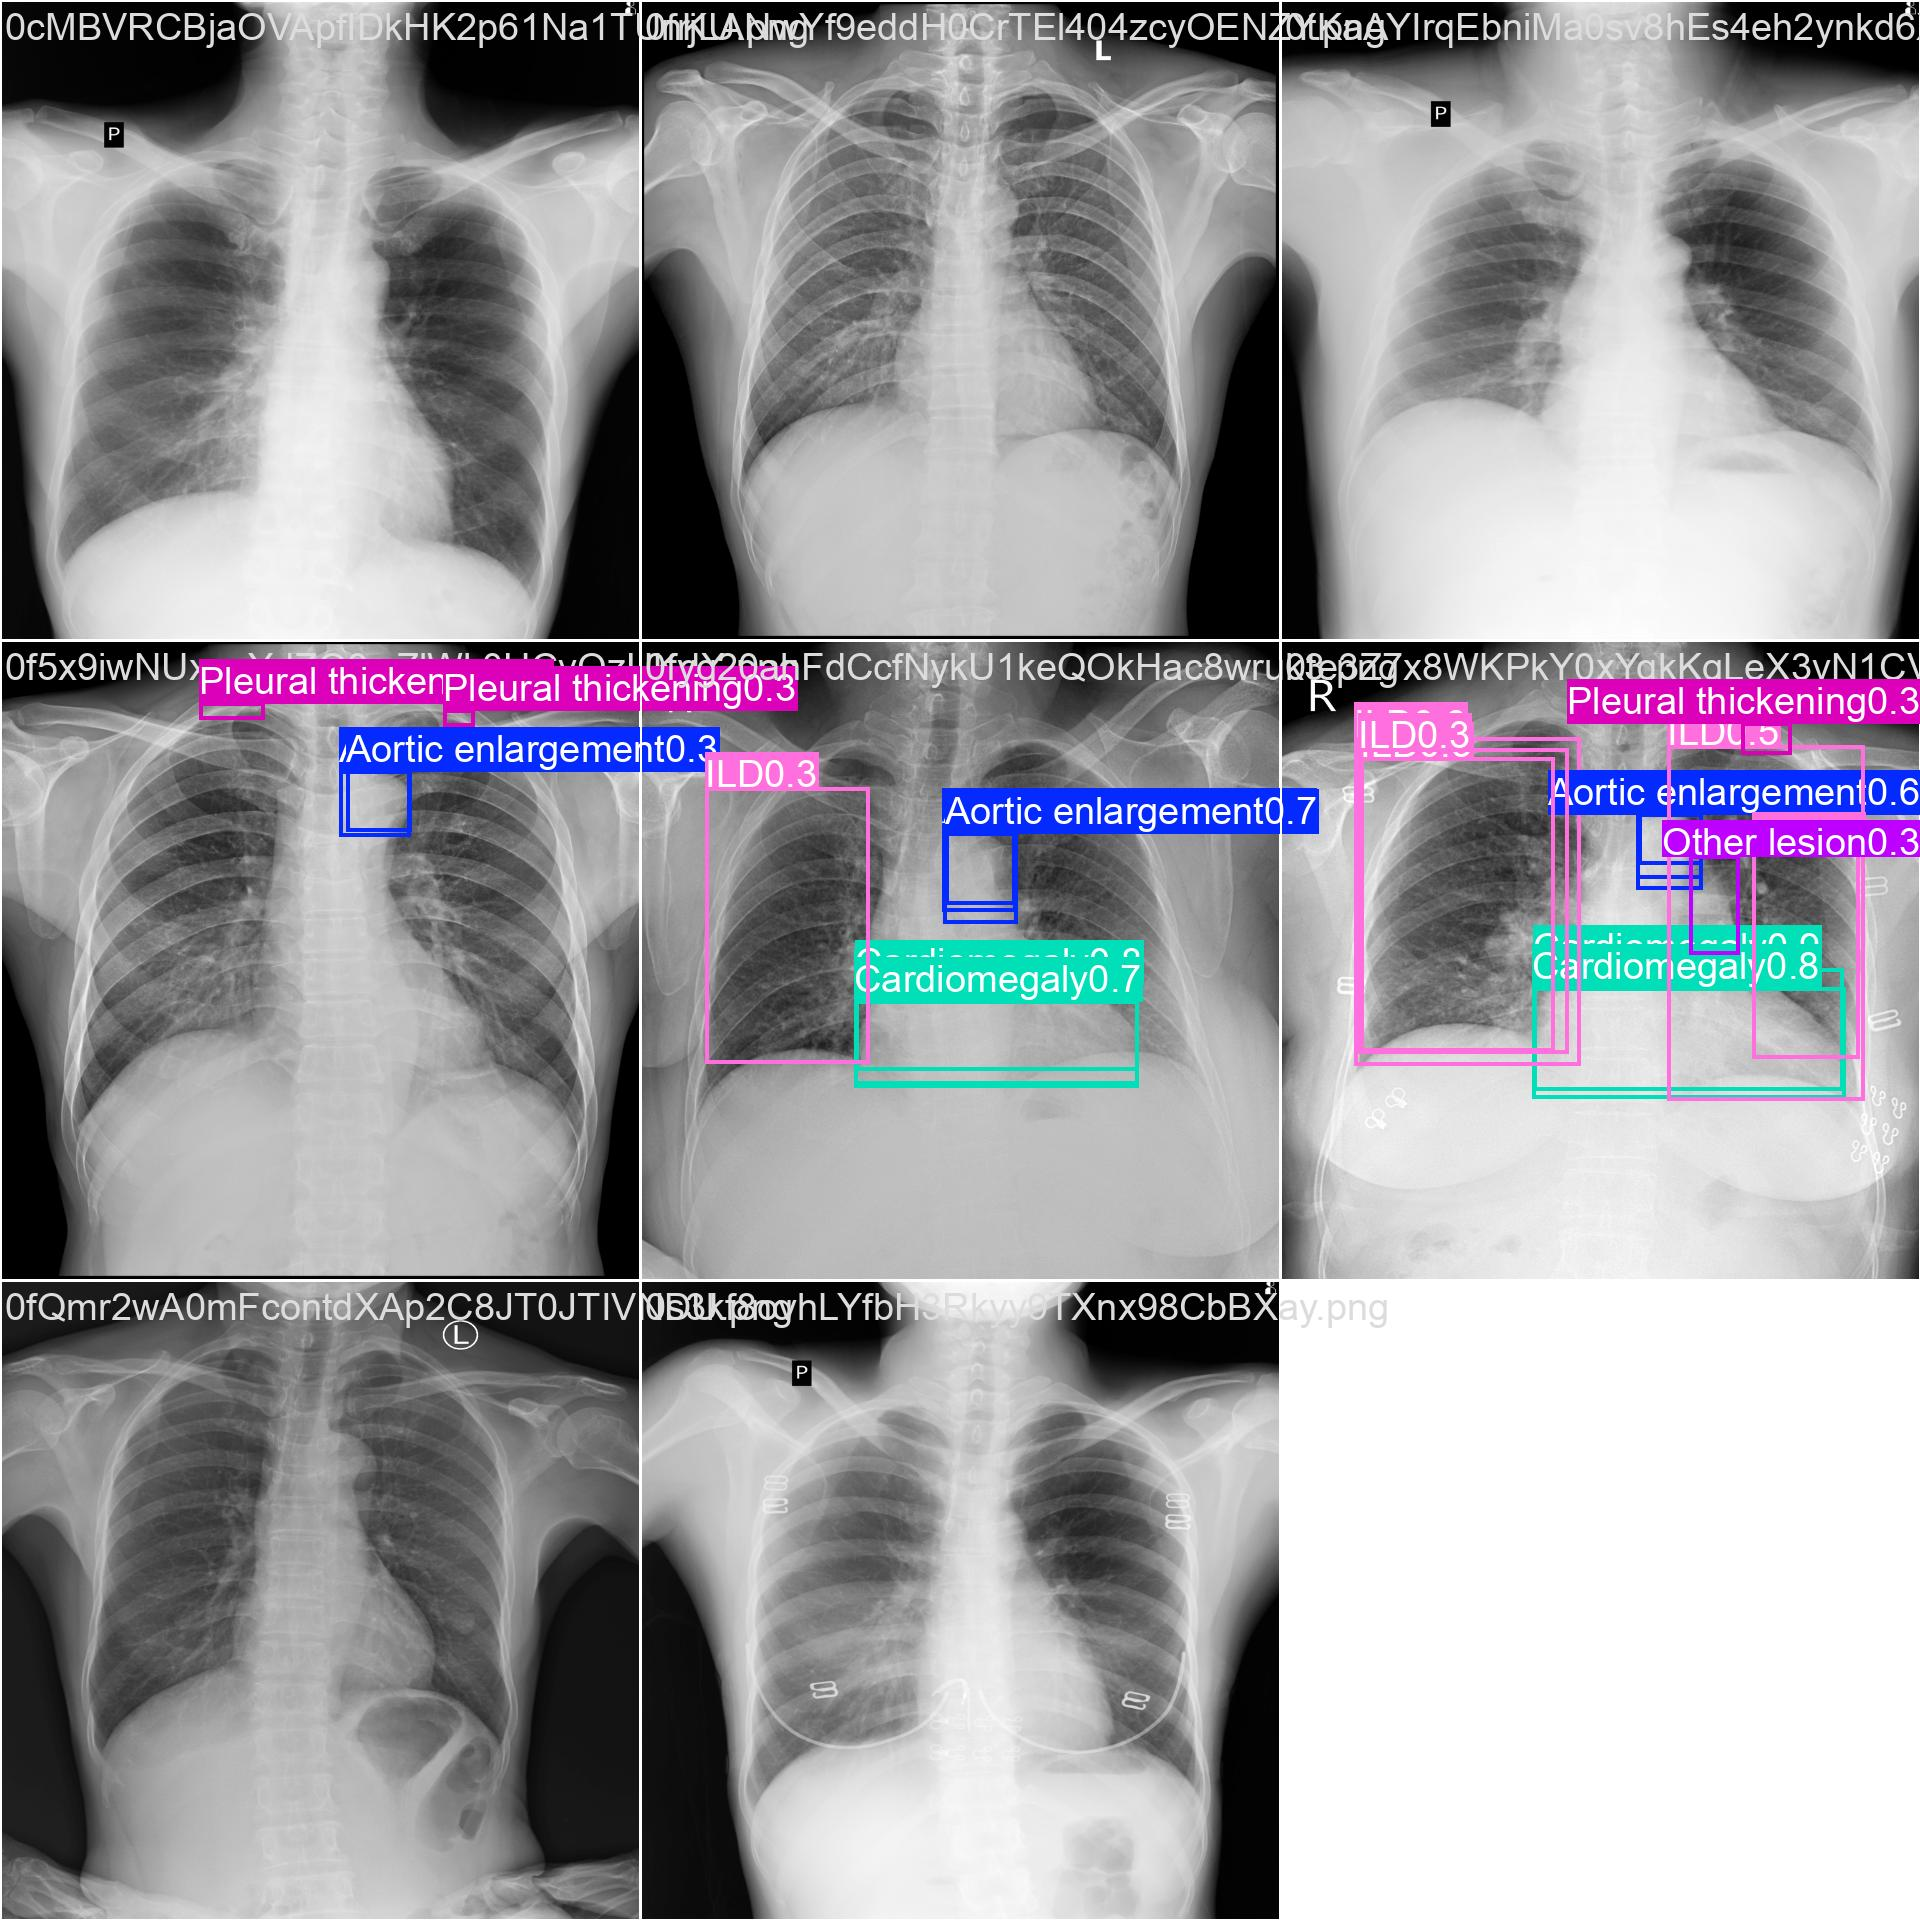

In [36]:
for batch_index in range(3):
    print(f"Validation batch {batch_index}: labels")
    show_artifact(f"val_batch{batch_index}_labels.jpg", width=760)
    print(f"Validation batch {batch_index}: predictions")
    show_artifact(f"val_batch{batch_index}_pred.jpg", width=760)


## 2.15. Submission behavior

The final submission uses confidence threshold $0.05$, IoU threshold $0.4$, and at most 300 detections per image. These values are permissive: the goal is to retain uncertain medical findings and let the scoring rule handle confidence ordering. Empty-image behavior is represented through the `No finding` class.

Let $T_s$ be the score threshold. The submitted set is approximately

$$
\widehat{Y}_{sub}(x)=\{(\widehat c_k,\widehat b_k,\widehat s_k):\widehat s_k\ge T_s\},
$$

followed by formatting into the competition CSV contract. If this set is empty, the post-processing writes a `No finding` row.


{
  "expected_rows": 6427,
  "output": "/kaggle/working/models/rtdetr-l-e20-b8-t4x2-ddpfix-t10h5/submission.csv",
  "prediction_batch": 8,
  "prediction_chunk_size": 128,
  "prediction_conf": 0.05,
  "prediction_iou": 0.4,
  "prediction_max_detections": 300,
  "rows": 6427
}


,class_id,detections,class_name
3,11,22409,Pleural thickening
14,9,14243,Other lesion
5,13,14233,Pulmonary fibrosis
12,7,8329,Lung Opacity
10,5,7825,ILD
0,0,6241,Aortic enlargement
13,8,5118,Nodule/Mass
8,3,5017,Cardiomegaly
11,6,4757,Infiltration
6,14,4067,No finding


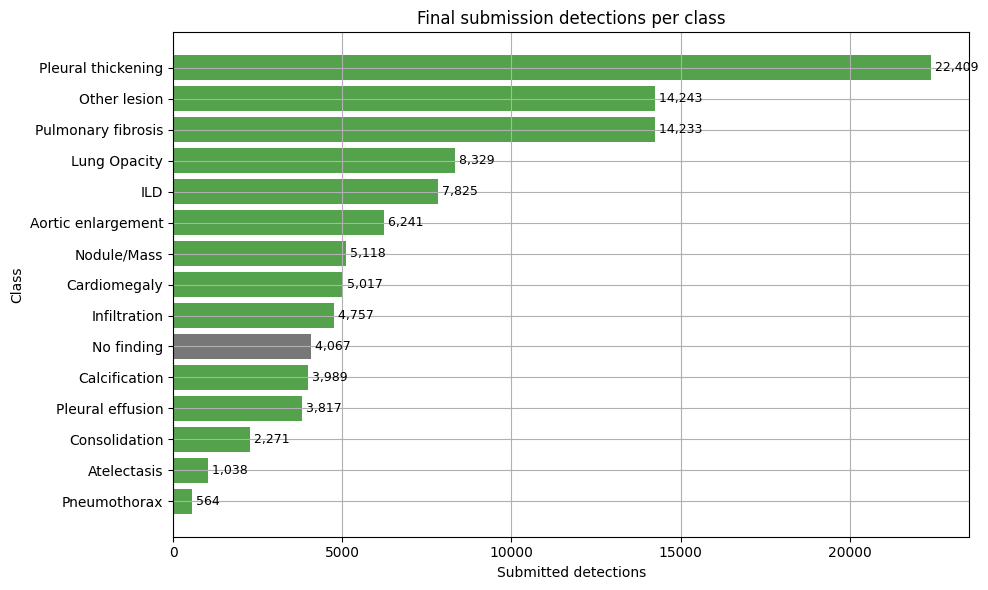

In [37]:
with open(paths["submission_summary"], "r", encoding="utf-8") as handle:
    submission_summary = json.load(handle)

print(json.dumps({key: value for key, value in submission_summary.items() if key != "detection_counts_by_class"}, indent=2))

submission_counts = pd.Series(submission_summary["detection_counts_by_class"], name="detections").rename_axis("class_id").reset_index()
submission_counts["class_id"] = submission_counts["class_id"].astype(int)
class_name_map = class_counts.set_index("class_id")["class_name"].to_dict()
submission_counts["class_name"] = submission_counts["class_id"].map(class_name_map)
submission_counts = submission_counts.sort_values("detections", ascending=False)
display(submission_counts)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = submission_counts.sort_values("detections", ascending=True)
colors = np.where(plot_df["class_id"].eq(14), "#777777", "#54A24B")
ax.barh(plot_df["class_name"], plot_df["detections"], color=colors)
ax.set_xlabel("Submitted detections")
ax.set_ylabel("Class")
ax.set_title("Final submission detections per class")
for index, value in enumerate(plot_df["detections"]):
    ax.text(value, index, f" {value:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 2.16. Interpretation and limitations

The trained RT-DETR-L run is a reasonable solution because it aligns with the mathematical structure of the task: each image maps to a set of localized findings, and DETR-style matching trains a set predictor directly. The large variant gives enough capacity for global radiographic context and transfer learning across imbalanced classes.

The strongest empirical evidence in this repository is the saved run directory: it contains the final checkpoint, training curves, validation metrics, confusion matrices, confidence curves, and qualitative prediction images. The best recorded validation row reaches a nontrivial but still limited `mAP50-95`, which is expected for a time-limited medical-detection run with many subtle classes and strong imbalance.

The main limitations are:

- the local notebook does not retrain the model, because the training run was GPU/Kaggle dependent;
- the local execution environment may not include Ultralytics/PyTorch, so checkpoint loading is environment-dependent;
- the model was trained under a wall-clock budget, so the results should be interpreted as a practical competition solution rather than a fully converged detector study;
- rare classes have limited annotation support, which makes per-class AP less stable and increases the value of qualitative review.

The final contract is nevertheless explicit: detector classes are `0..13`, `No finding` is a submission fallback, `best.pt` is the selected trained artifact, and the saved submission has one row per expected test image.
